# CVLAB Summer Project — Stage 1: Classification Baselines

**DTD · FGVC-Aircraft · Oxford Flowers-102 | frozen pretrained encoders**

The goal of Stage 1 is a reliable, reproducible classification pipeline built on **frozen** pretrained encoders. No flow-matching component appears at this stage: the selected prototype branch carries into Stage 2, and the linear-probe setting carries into Stage 3.

The specification (`_docs/stage_1.pdf`) lists three candidate baselines and asks each group to implement the linear probe plus **one** of the two prototype branches. We implement all three so the branch that continues into Stage 2 can be chosen from measured results:

1. **Linear probe** (required) — a multiclass linear classifier $s = Wz + b$ on frozen features, softmax cross-entropy, only $W$ and $b$ trained.
2. **Image-derived class prototypes** (branch A) — $\mu_c = \mathrm{normalize}\left(\frac{1}{|S_c|}\sum_{i \in S_c} \mathrm{normalize}(z_i)\right)$, classify by $\hat{y} = \arg\max_c \cos(z, \mu_c)$.
3. **Zero-shot CLIP** (branch B) — text-derived class prototypes from CLIP RN50 prompts, $\hat{y} = \arg\max_c \cos(z, t_c)$; uses no labeled training images.

**Protocol.** All classes, official train / validation / test splits, never merging train and validation. Training-set sizes $K \in \{5, 10, \text{full}\}$ images per class; the 5- and 10-shot settings use balanced subsets of the official training split with seeds $\{0,1,2\}$. The validation split is used for model selection (linear-probe checkpointing) and the **complete official test split** only for the final top-1 accuracy.

**Group choices** (documented in `docs/adr/0005-group-choices-within-the-spec.md`): the specification allows any two of the three datasets; **our selected pair is DTD + FGVC-Aircraft** (their training splits make the three K settings genuinely distinct), and Flowers-102 is run additionally, marked ‡ throughout. DINOv2 ViT-S/14 is used on FGVC-Aircraft, the fine-grained task. ResNet-18 is used on all datasets. CLIP RN50 is used for the zero-shot branch only, as the spec restricts it.

## 1 · Environment and configuration

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json

import pandas as pd
from IPython.display import Image, display

from src.utils import load_config

pd.set_option("display.precision", 2)
pd.set_option("display.max_rows", 200)

with open(REPO / "results" / "runtime_summary.json") as f:
    runtime = json.load(f)
print("Runtime:", json.dumps(runtime, indent=2))

cfg = load_config()
print("\nTraining-set sizes K:", cfg["shots"])
print("Subset seeds (5/10-shot):", cfg["subset_seeds"],
      "| initialization seeds (full):", cfg["init_seeds"])
print("Linear probe:", json.dumps(cfg["linear_probe"], indent=2))

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Training-set sizes K: [5, 10, 'full']
Subset seeds (5/10-shot): [0, 1, 2] | initialization seeds (full): [0, 1, 2]
Linear probe: {
  "optimizer": "adamw",
  "lr": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 64,
  "max_epochs": 200,
  "checkpoint_selection": "highest_validation_accuracy"
}


All experiments ran on the machine above. Every encoder is **frozen** and used with the preprocessing associated with its own checkpoint:

| Encoder | Source | Representation | Used on |
|---|---|---|---|
| ResNet-18 (ImageNet-1K) | torchvision `ResNet18_Weights.IMAGENET1K_V1` | 512-d, before the final classification layer | all datasets |
| DINOv2 ViT-S/14 | `facebook/dinov2-small` | final class token (384-d) | FGVC-Aircraft |
| CLIP RN50 | official OpenAI `clip` | image encoder (1024-d) + text encoder | zero-shot branch only |

Train, validation and test features are extracted **once** per (dataset, encoder) and cached; all classifier training and evaluation runs on those caches.

## 2 · Datasets, official splits and training subsets

All classes are used, with the **official** splits: DTD uses partition 1, FGVC-Aircraft uses the `variant` annotation level, Flowers-102 uses its published split. Training and validation splits are never merged.

In [2]:
splits = pd.read_csv(REPO / "results" / "metrics" / "dataset_splits.csv")
display(splits)

,Dataset,dataset,split,images,classes,per_class_min,per_class_median,per_class_max,spec_selected
0,DTD,dtd,train,1880,47,40,40,40,True
1,DTD,dtd,val,1880,47,40,40,40,True
2,DTD,dtd,test,1880,47,40,40,40,True
3,FGVC-Aircraft,fgvc_aircraft,train,3334,100,33,33,34,True
4,FGVC-Aircraft,fgvc_aircraft,val,3333,100,33,33,34,True
5,FGVC-Aircraft,fgvc_aircraft,test,3333,100,33,33,34,True
6,Oxford Flowers-102 ‡,flowers102,train,1020,102,10,10,10,False
7,Oxford Flowers-102 ‡,flowers102,val,1020,102,10,10,10,False
8,Oxford Flowers-102 ‡,flowers102,test,6149,102,20,46,238,False


For the 5-shot and 10-shot settings a **balanced** subset of the official training split is sampled with seeds {0, 1, 2}; the chosen indices are saved under `results/artifacts/subsets/` so that every encoder and every classification head is trained on bit-identical images. The `full` setting is the complete official training split.

Note the structural quirk visible in the table: Flowers-102's official training split contains exactly 10 images per class, so for that dataset the 10-shot setting *is* the full setting (its three 10-shot "runs" therefore see identical data and the spread is exactly zero). DTD (40 per class) and FGVC-Aircraft (~33 per class) give three genuinely distinct settings — which is why we selected them as our dataset pair (the specification allows any two of the three).

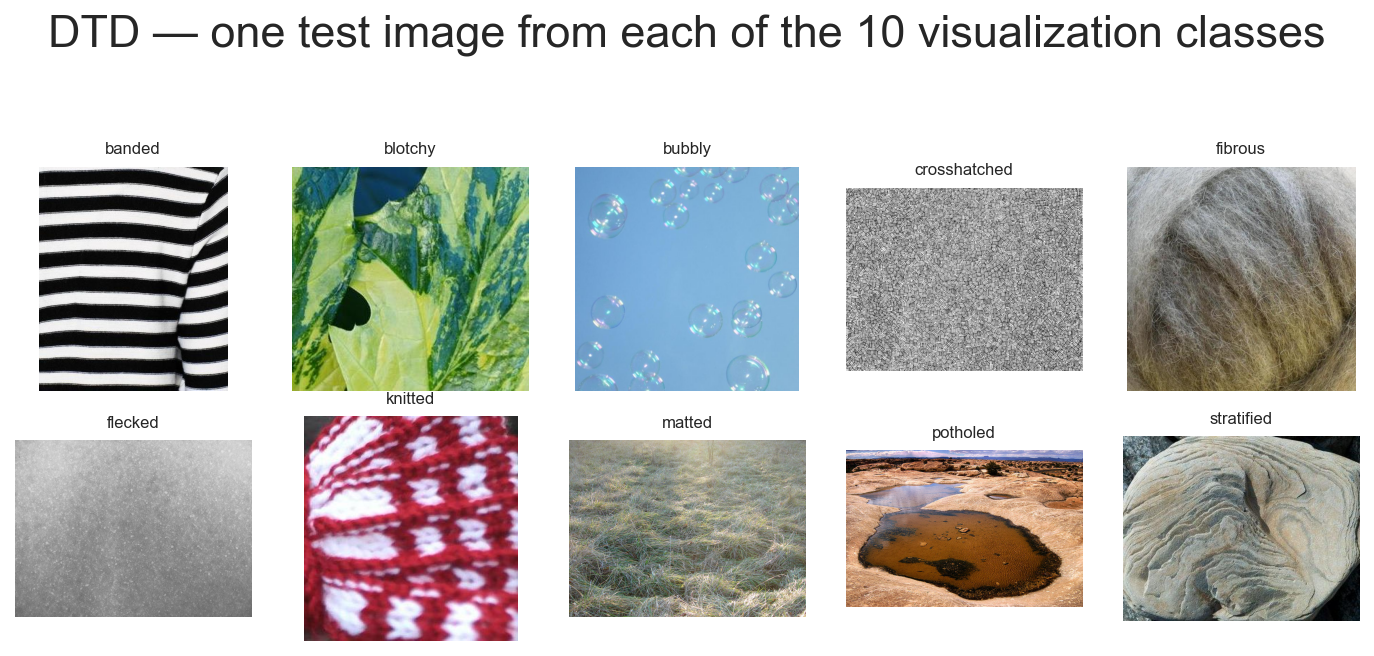

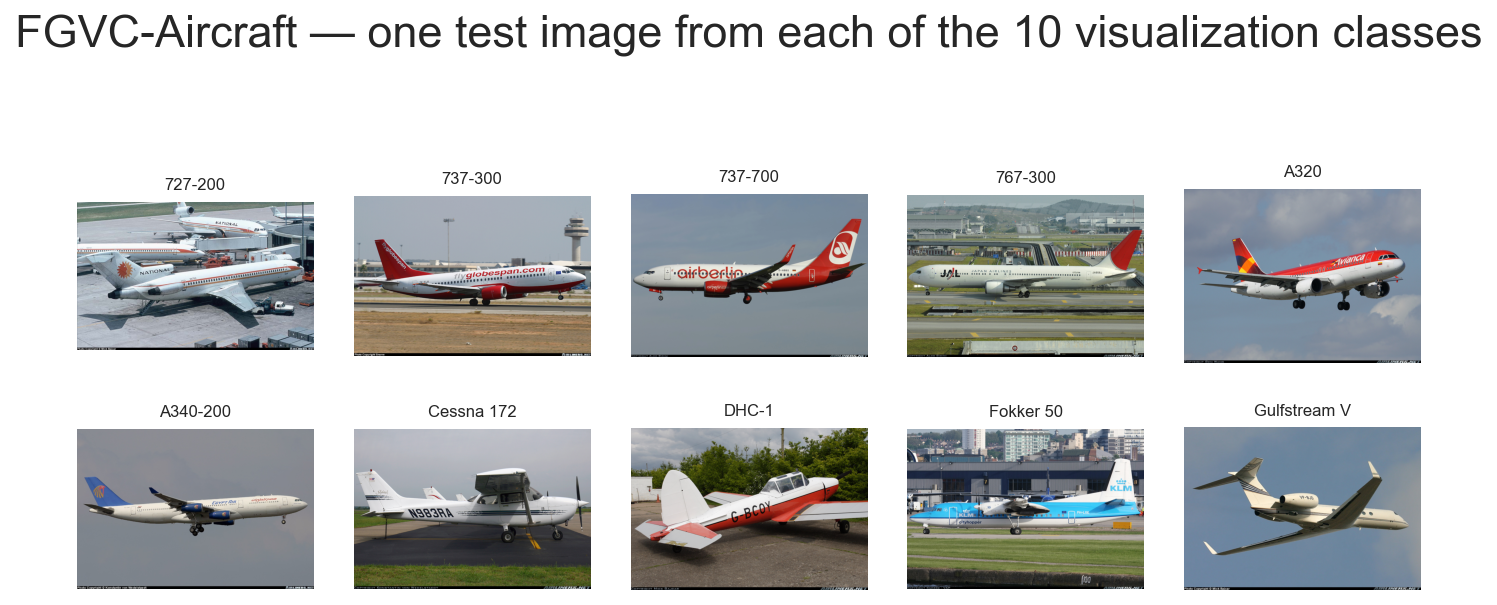

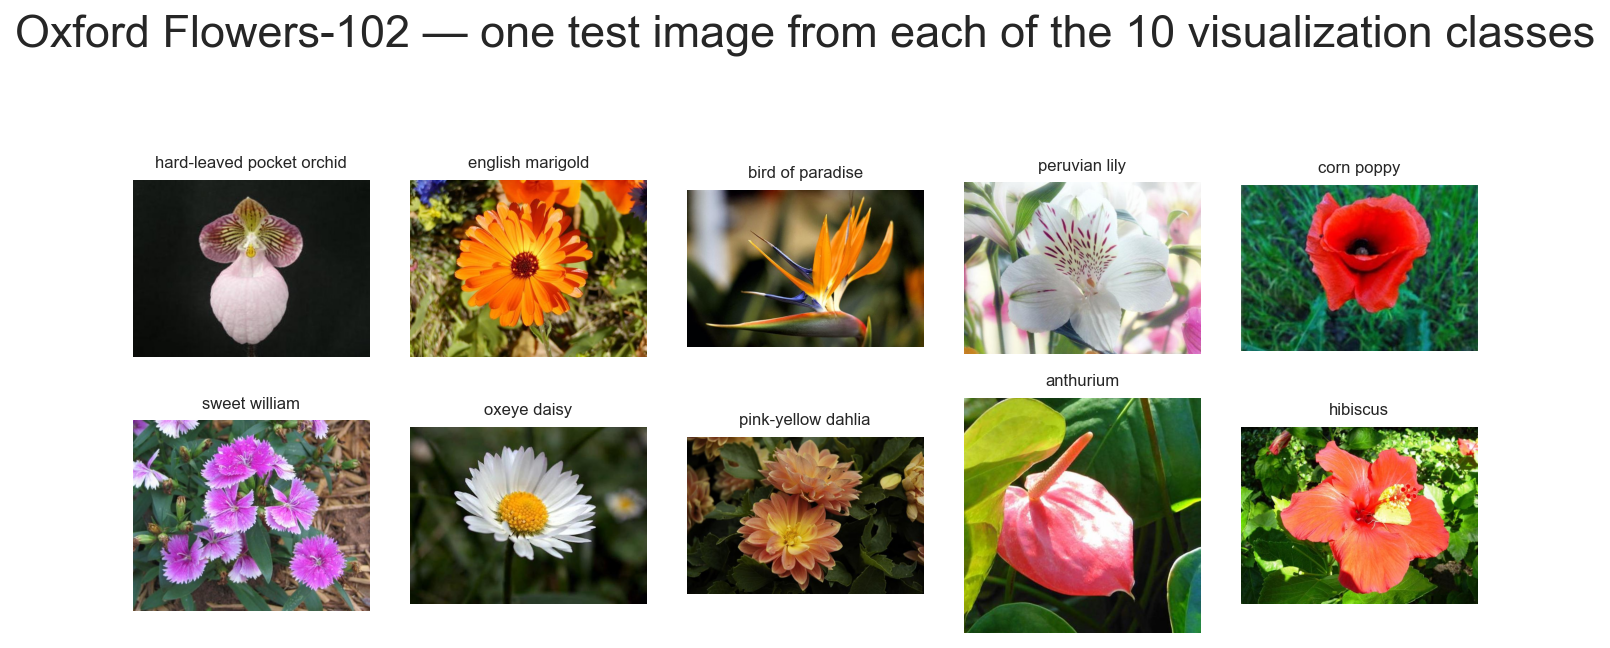

In [3]:
display(Image(str(REPO / "results" / "figures" / "samples_dtd.png"), width=760))
display(Image(str(REPO / "results" / "figures" / "samples_fgvc_aircraft.png"), width=760))
display(Image(str(REPO / "results" / "figures" / "samples_flowers102.png"), width=760))

## 3 · Methods

**Linear probe (required baseline).** A multiclass linear classifier $s = Wz + b$ over the frozen feature $z$; only $W$ and $b$ are trained, with softmax cross-entropy. The configuration is the one suggested by the specification, adopted unchanged and fixed a priori — AdamW, learning rate $10^{-3}$, weight decay $10^{-4}$, batch size 64, at most 200 epochs, and **checkpoint selection by highest validation accuracy**. No hyperparameter search was performed; the objective is a reasonable, stable probe, since the later comparison of interest concerns the FM layer.

**Image-derived class prototypes (branch A).** Features are $L_2$-normalized first, then

$$\mu_c = \mathrm{normalize}\left(\frac{1}{|S_c|}\sum_{i \in S_c} \mathrm{normalize}(z_i)\right), \qquad \hat{y} = \arg\max_c \cos(z, \mu_c),$$

where $S_c$ is the selected **training** subset for class $c$. There is nothing to train and no initialization, so the only source of run-to-run variation is which training images the subset seed selected.

**Zero-shot CLIP (branch B).** One text prototype per class from the frozen CLIP RN50 text encoder, using the dataset-specific prompt from the spec — `a photo of a {class} texture` (DTD), `a photo of a {class} aircraft` (FGVC-Aircraft), `a photo of a {class} flower` (Flowers-102). Image and text embeddings are normalized and classified with $\hat{y} = \arg\max_c \cos(z, t_c)$. This branch uses **no labeled training images**, so it produces exactly one result per dataset and is drawn as a horizontal reference line rather than a curve.

## 4 · Protocol integrity and provenance

Everything a reader needs to judge the numbers, in one place.

**Split discipline.** All classes, official train / validation / test splits, train and validation never merged. The validation split is used *only* for linear-probe checkpoint selection (highest validation accuracy). The complete official **test** split is used only for the final top-1 numbers reported below — no hyperparameter, encoder, subset or checkpoint was ever chosen by looking at test accuracy. Decisions that feed forward into Stage 2/3 — the representative encoder shown in figures and the Stage-2 branch selection (§6) — are likewise made from **validation** accuracies and methodological considerations, never from test results.

**Run and seed structure** (3 runs per training-set size, exactly as specified):

| Setting | What varies across the 3 runs | What is held fixed |
|---|---|---|
| 5-shot, 10-shot | balanced-subset seed ∈ {0, 1, 2} | classifier initialization (seed 0) |
| full — linear probe | classifier-initialization seed ∈ {0, 1, 2} | training set (the complete official split) |
| full — image prototypes | *nothing* — single deterministic run | — |
| zero-shot CLIP | *nothing* — single deterministic run, no training images | — |

Each setting therefore has a single interpretable source of variance: subset sampling at 5/10-shot, initialization at full. Single-run settings are reported without a standard deviation rather than as "± 0.00".

**Hyperparameter provenance.** The linear-probe configuration is the specification's suggested baseline, adopted unchanged and fixed before any result was observed: AdamW, lr 1e-3, weight decay 1e-4, batch size 64, ≤200 epochs, checkpoint on best validation accuracy. Feature extraction uses each checkpoint's own preprocessing. All values live in `config/config.json`; none was tuned.

**Reproducibility.** Balanced training subsets are saved as index files (`results/artifacts/subsets/`) carrying a fingerprint of the training-split labels, so every encoder and head trains on identical images and a dataset change fails loudly instead of silently shifting the data. Per-run accuracies are saved to `results/metrics/raw/`; `scripts/repro_check.py` re-derives every mean and standard deviation in the tables below from those raw arrays.

In [4]:
runs = pd.read_csv(REPO / "results" / "metrics" / "runs.csv")
print("individual runs recorded:", len(runs))
display(runs.groupby(["head", "k_shot"], sort=False)
            .agg(runs=("test_acc", "size"), seed_type=("seed_type", "first"))
            .reset_index())

individual runs recorded: 67


,head,k_shot,runs,seed_type
0,linear_probe,5shot,12,subset
1,image_prototype,5shot,12,subset
2,linear_probe,10shot,12,subset
3,image_prototype,10shot,12,subset
4,linear_probe,full,12,init
5,image_prototype,full,4,subset
6,zeroshot_clip,none,3,deterministic


## 5 · Results

### 5.1 Accuracy table

Top-1 accuracy (%) on the complete official test split, for every dataset, encoder, training-set size and implemented baseline. Generated programmatically from `results/metrics/summary.csv`; ‡ marks the dataset beyond our selected pair (the specification allows any two of the three). Statistics are the sample standard deviation (ddof = 1) over the 3 runs.

In [5]:
from IPython.display import Markdown

display(Markdown((REPO / "results" / "metrics" / "accuracy_table.md").read_text(encoding="utf-8")))

| Dataset | Encoder | Baseline | K = 5 | K = 10 | full train split | no training images |
|---|---|---|---|---|---|---|
| DTD | ResNet-18 | Linear probe | 45.60 ± 0.64 | **54.31 ± 0.28** | **62.84 ± 0.45** | — |
| DTD | ResNet-18 | Image prototypes | **46.51 ± 0.64** | 53.37 ± 1.04 | 58.78 | — |
| DTD | CLIP RN50 | Zero-shot CLIP | — | — | — | 39.79 |
| FGVC-Aircraft | ResNet-18 | Linear probe | 19.90 ± 1.72 | 27.36 ± 0.83 | 36.62 ± 0.27 | — |
| FGVC-Aircraft | ResNet-18 | Image prototypes | 16.04 ± 0.83 | 19.85 ± 0.47 | 25.20 | — |
| FGVC-Aircraft | DINOv2 | Linear probe | **36.47 ± 0.70** | **51.30 ± 0.95** | **67.21 ± 0.11** | — |
| FGVC-Aircraft | DINOv2 | Image prototypes | 23.11 ± 1.36 | 27.80 ± 1.17 | 34.41 | — |
| FGVC-Aircraft | CLIP RN50 | Zero-shot CLIP | — | — | — | 17.04 |
| Oxford Flowers-102 ‡ | ResNet-18 | Linear probe | **75.58 ± 0.84** | **83.22 ± 0.00** | **83.28 ± 0.11** | — |
| Oxford Flowers-102 ‡ | ResNet-18 | Image prototypes | 70.19 ± 0.14 | 75.22 ± 0.00 | 75.22 | — |
| Oxford Flowers-102 ‡ | CLIP RN50 | Zero-shot CLIP | — | — | — | 63.64 |

**Bold** marks the best supervised configuration in each (dataset, training-set size) column; zero-shot CLIP is excluded from that comparison because it uses no training images. Top-1 accuracy (%) on the complete official test split. 5-shot / 10-shot: mean ± std over 3 training-subset seeds; full linear probe: mean ± std over 3 initialization seeds; full image prototypes and zero-shot CLIP are single deterministic runs. Zero-shot CLIP uses no labeled training images, so it has one value only. ‡ = beyond our selected dataset pair (the specification asks for any two of the three; we selected DTD + FGVC-Aircraft and additionally ran the third). A standard deviation of exactly 0.00 at Flowers-102 K = 10 is not a rounding artifact: that dataset's official training split holds exactly 10 images per class, so all three 10-shot subsets are the same set of images.

**External sanity check.** Our CLIP RN50 zero-shot results (DTD 39.8, FGVC-Aircraft 17.0, Flowers-102 63.6) sit just below the values commonly reported for this checkpoint (≈ 41.7, 19.3, 65.9 — Radford et al. 2021, Table 11, and the prompt-ensemble notebook in the official CLIP repository), which is what we expect from using the specification's single prompt rather than an ensemble of 80.

**Paired head comparison.** At a given (dataset, encoder, K) both supervised heads train on the *same* committed subset indices and are evaluated on the same test split, so per-seed differences are matched and far tighter than the marginal spreads. This is the statistic that actually supports the one prototype win:

In [6]:
display(Markdown((REPO / "results" / "metrics" / "paired_heads_table.md").read_text(encoding="utf-8")))

| Dataset | Encoder | K | Prototypes − probe (paired) | Seeds favouring prototypes |
|---|---|---|---|---|
| DTD | ResNet-18 | 5 | +0.90 ± 0.14 | 3 / 3 |
| DTD | ResNet-18 | 10 | -0.94 ± 0.83 | 0 / 3 |
| FGVC-Aircraft | ResNet-18 | 5 | -3.86 ± 0.95 | 0 / 3 |
| FGVC-Aircraft | ResNet-18 | 10 | -7.51 ± 1.11 | 0 / 3 |
| FGVC-Aircraft | DINOv2 | 5 | -13.36 ± 0.81 | 0 / 3 |
| FGVC-Aircraft | DINOv2 | 10 | -23.49 ± 0.94 | 0 / 3 |
| Oxford Flowers-102 ‡ | ResNet-18 | 5 | -5.39 ± 0.95 | 0 / 3 |
| Oxford Flowers-102 ‡ | ResNet-18 | 10 | -8.00 ± 0.00 | 0 / 3 |

Mean ± sample standard deviation (ddof = 1) of the per-seed difference in top-1 accuracy, both heads trained on identical subset indices. Positive favours image prototypes. The `full` setting is omitted because the prototype head runs once there and the probe varies only by initialization, so the runs are not paired.

The single prototype win — DTD at K = 5 — is **+0.90 ± 0.14 with all three seeds agreeing in sign**, a much stronger statement than the overlapping marginal intervals (46.51 ± 0.64 vs 45.60 ± 0.64) would justify on their own. Everywhere else the linear probe wins, by a margin that grows with the training-set size and reaches −23.5 points on FGVC-Aircraft/DINOv2 at K = 10.

**Balanced accuracy.** Flowers-102's official test split is class-imbalanced (20–238 images per class), so its image-weighted top-1 and per-class macro accuracy differ; DTD and FGVC-Aircraft are balanced and unaffected. The spec asks for plain top-1 (reported above); this matters only when comparing top-1 against the row-normalized confusion matrix in §5.4.

In [7]:
display(Markdown((REPO / "results" / "metrics" / "macro_accuracy_table.md").read_text(encoding="utf-8")))

| Dataset | Encoder | Top-1 (%) | Balanced / macro (%) |
|---|---|---|---|
| DTD | ResNet-18 | 63.35 | 63.35 |
| FGVC-Aircraft | DINOv2 | 67.09 | 67.07 |
| Oxford Flowers-102 ‡ | ResNet-18 | 83.22 | 85.38 |

Single full-split linear-probe run (initialization seed 0) on each dataset's best-by-validation encoder. The two columns coincide when the test split is balanced (DTD, FGVC-Aircraft) and diverge for Flowers-102, whose official test split is class-imbalanced.

### 5.2 Accuracy versus training-set size

Error bars are ± sample std over the 3 runs; the full-split prototype point and the zero-shot line are single deterministic runs. Zero-shot CLIP uses no labeled training images, so it is a horizontal reference rather than a curve.

**What to look for:** on DTD prototypes lead at K = 5 and the probe overtakes them by K = 10. On FGVC-Aircraft the *encoder* separates the curves far more than the head does — the DINOv2 probe at K = 5 (36.5%) already matches the ResNet-18 probe on the full split (36.6%). On Flowers-102 the 10-shot and full points coincide because the official training split holds exactly 10 images per class.

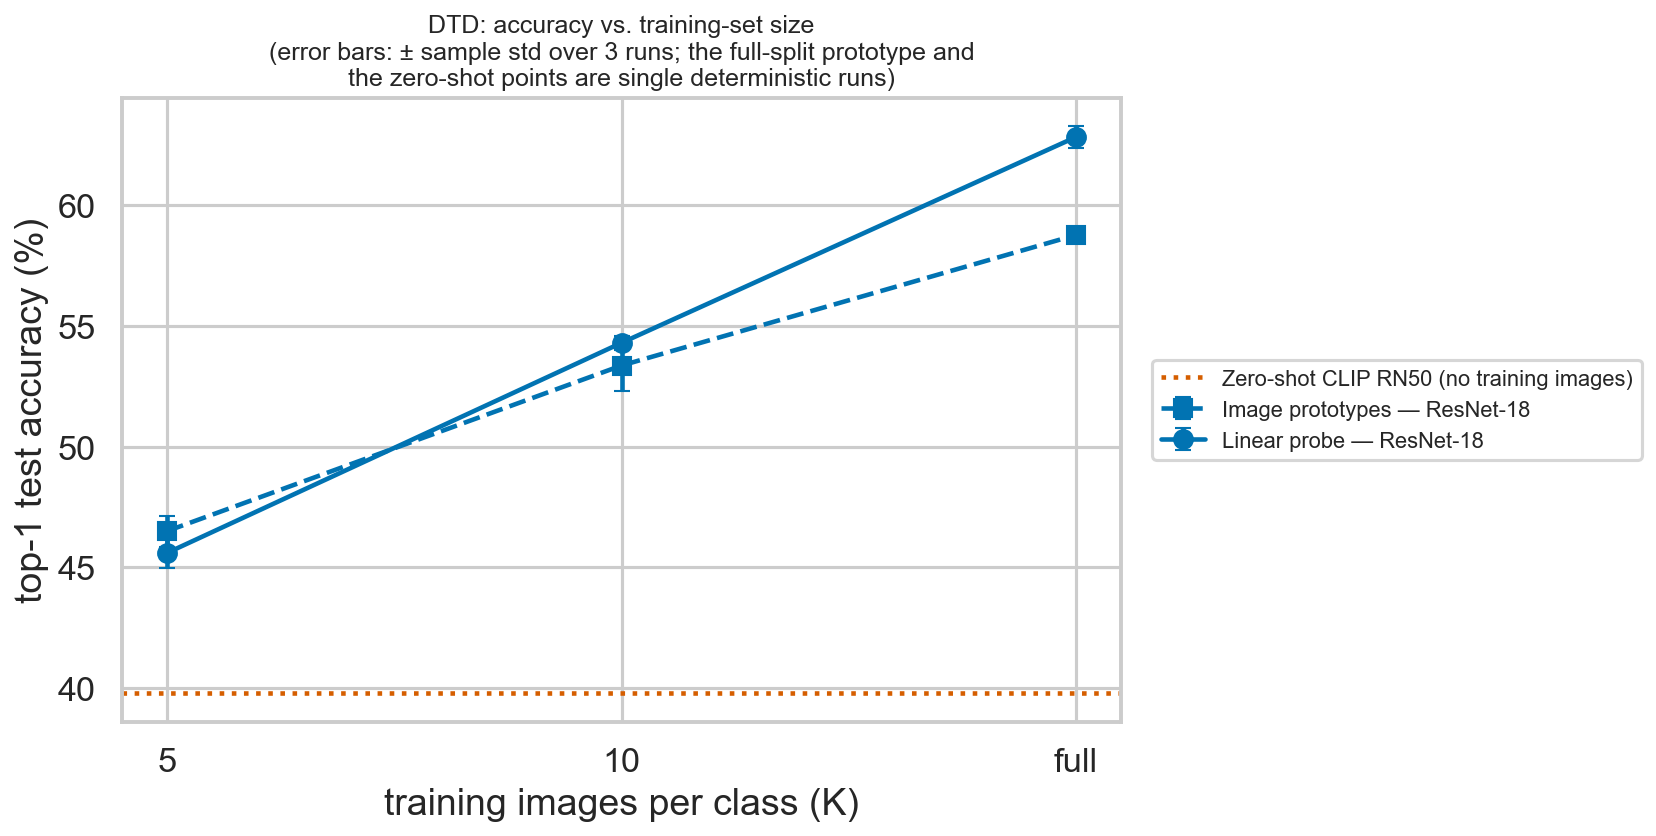

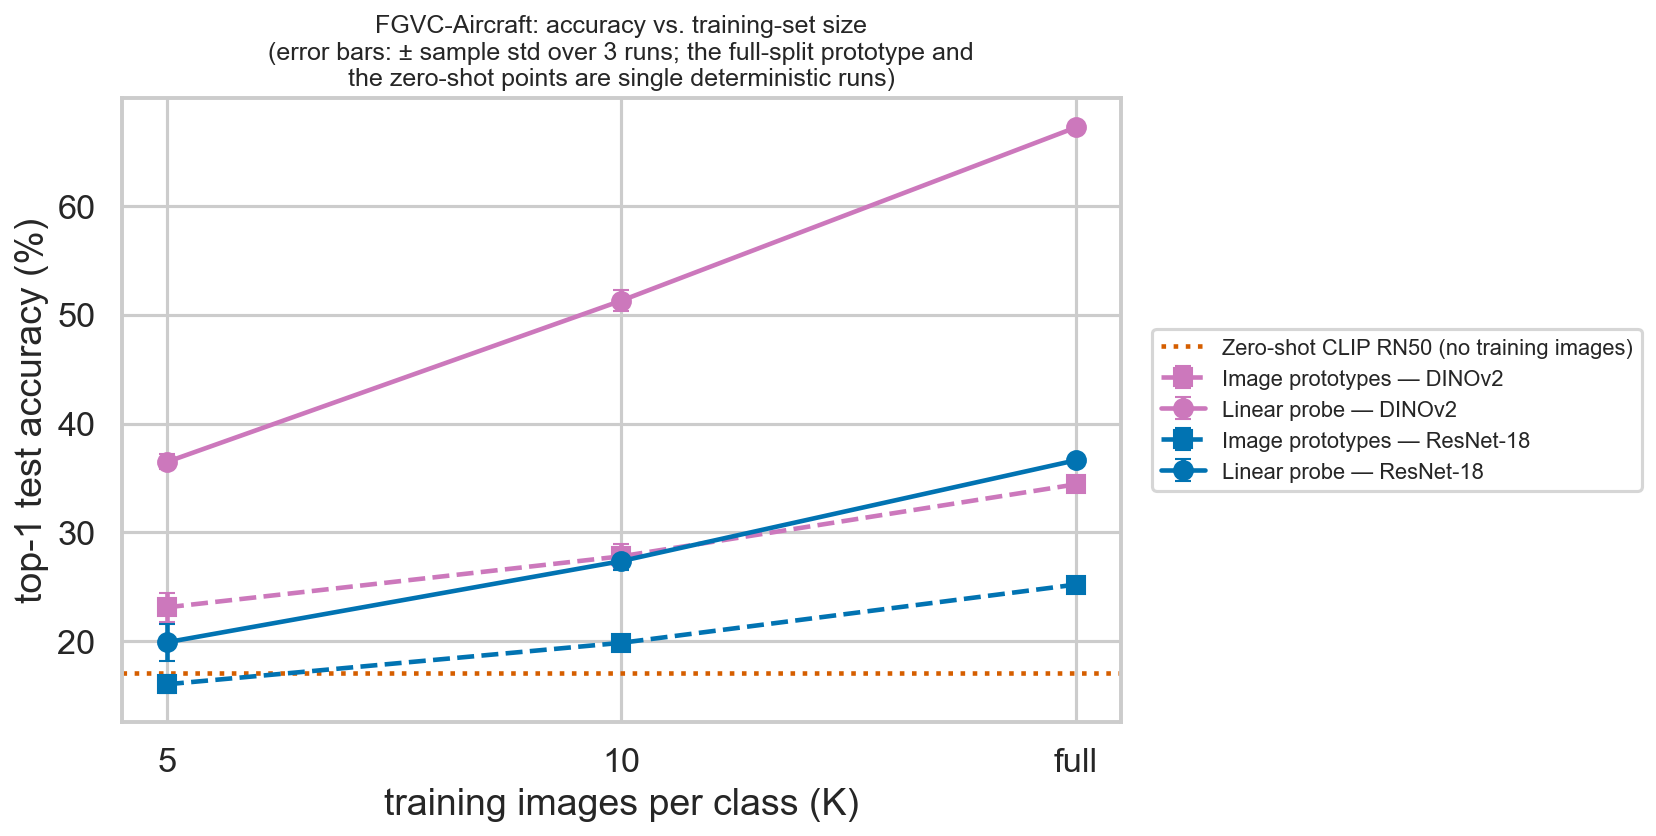

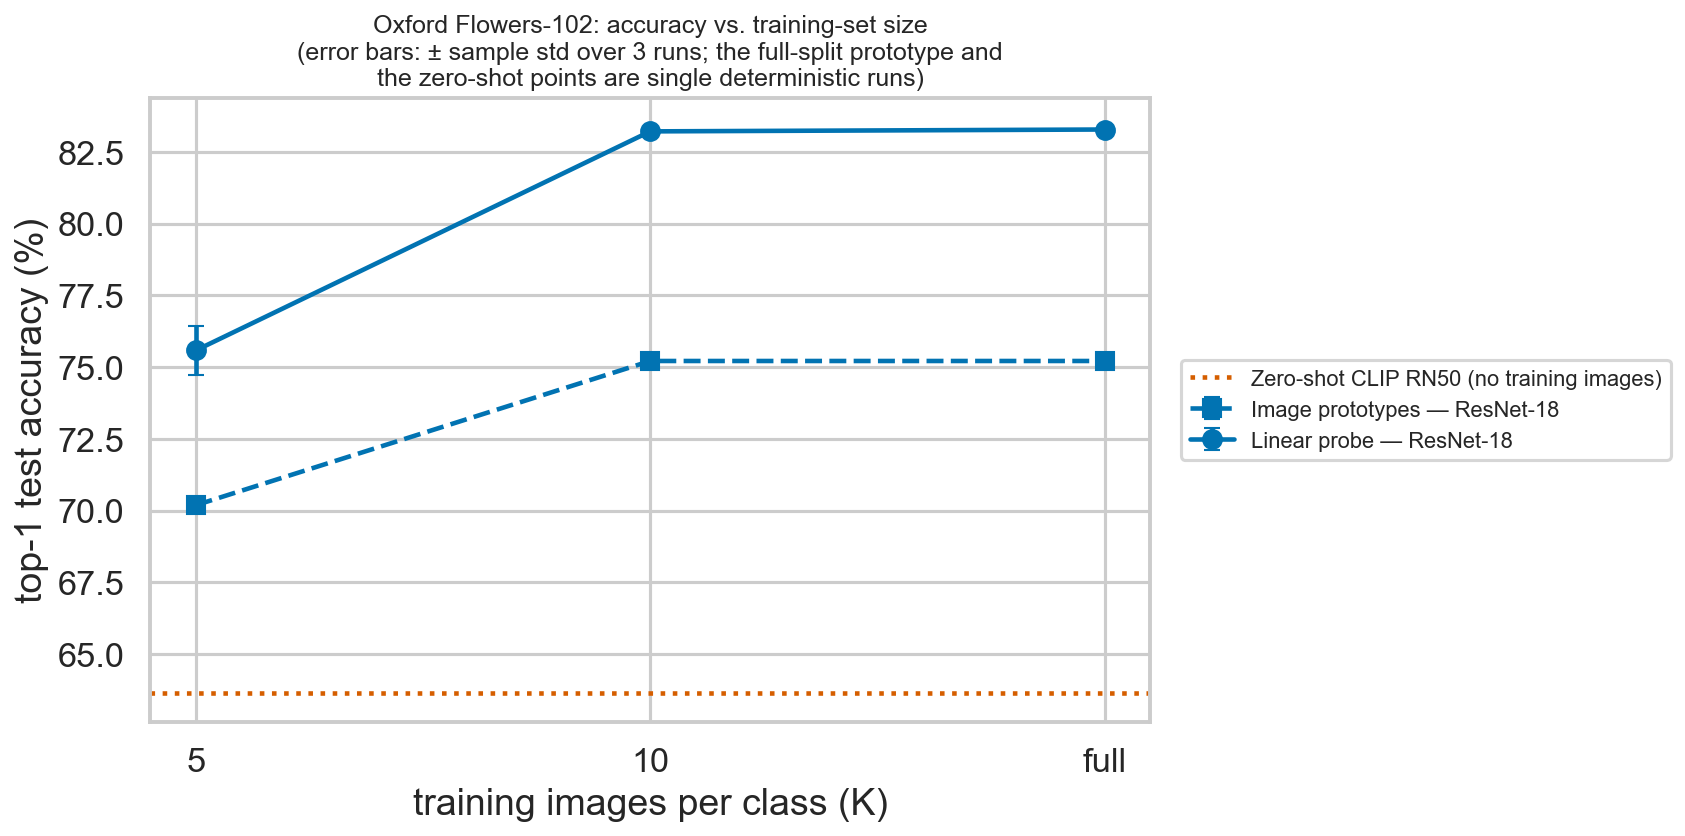

In [8]:
for ds in ("dtd", "fgvc_aircraft", "flowers102"):
    display(Image(str(REPO / "results" / "figures" / f"acc_vs_trainsize_{ds}.png"), width=820))

### 5.3 Linear-probe training curves

Representative 10-shot run (subset seed 0) for each dataset–encoder combination. The dashed line marks the selected checkpoint (highest validation accuracy); the dotted green curve is validation accuracy on the right-hand axis.

**What to look for:** training is smooth and monotone everywhere — the probe is stable. On DTD and FGVC-Aircraft the validation *loss* bottoms out near epoch 20–30 and then rises while training loss goes to zero: the probe overfits at this training-set size, and checkpoint selection on validation accuracy is what absorbs it. On FGVC-Aircraft/DINOv2 the validation loss rises from ~epoch 25 while validation *accuracy* keeps creeping up to its peak at epoch 187 — the probe grows over-confident on examples it already gets wrong, which cross-entropy punishes and top-1 accuracy does not. Loss and accuracy are therefore *not* interchangeable checkpoint criteria.

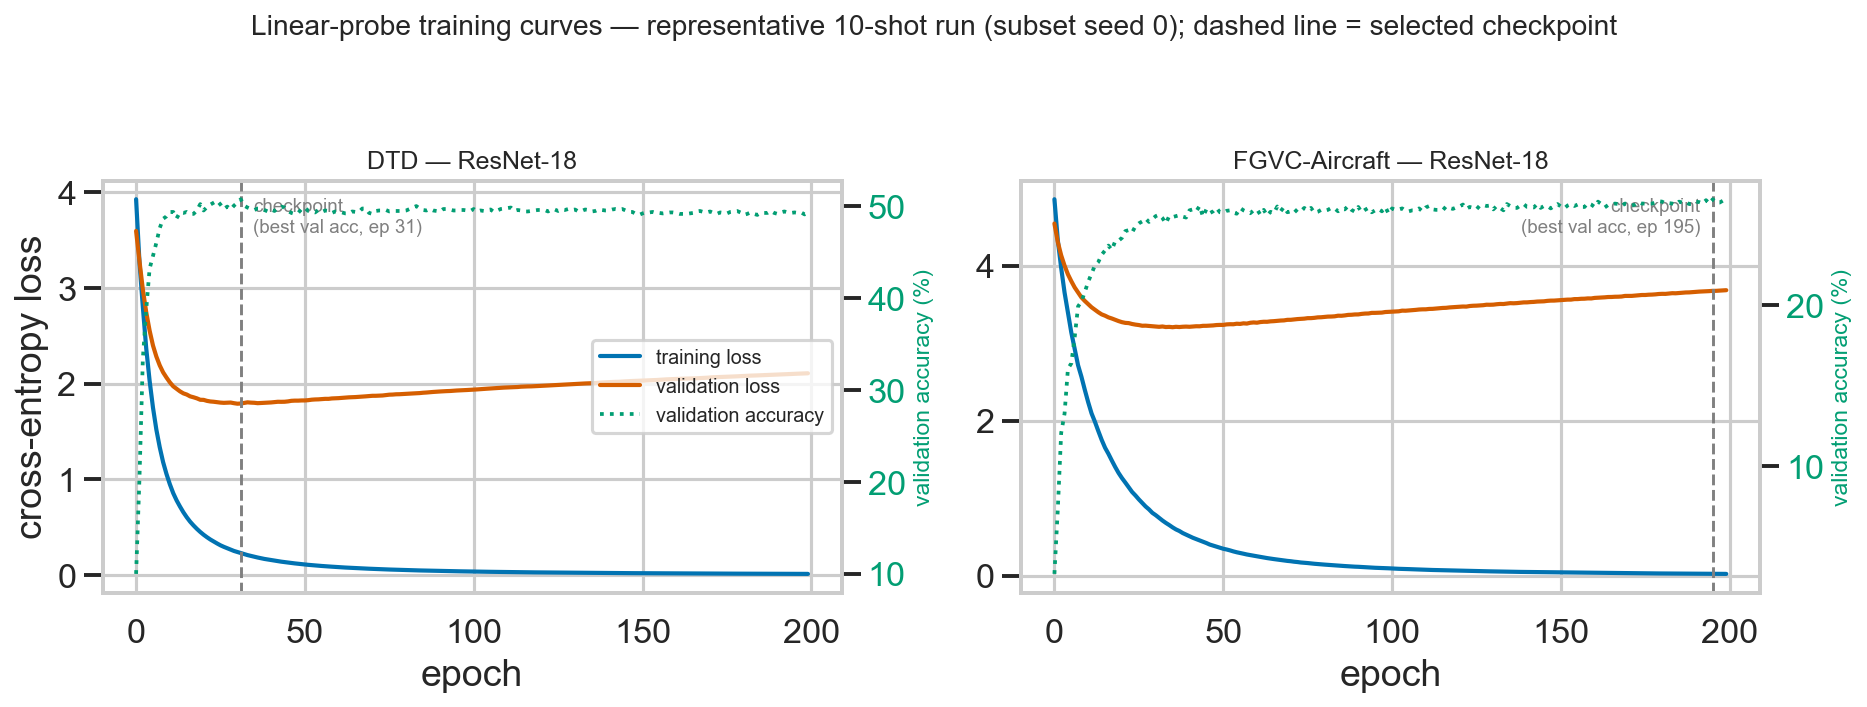

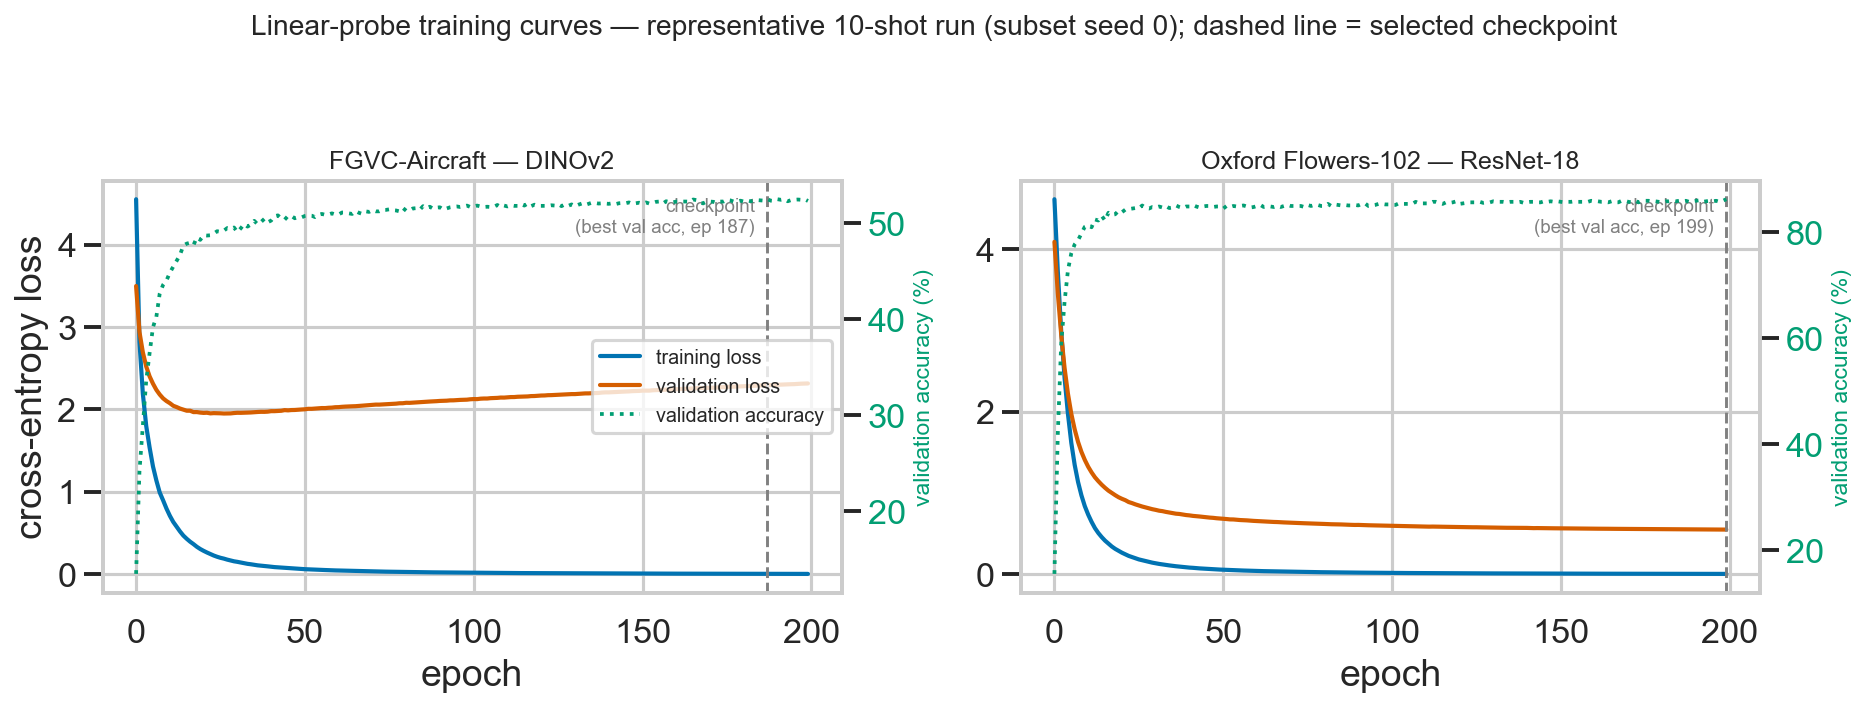

In [9]:
import glob

for p in sorted(glob.glob(str(REPO / "results" / "figures" / "training_curves_*.png"))):
    display(Image(p, width=980))

**Is the specification's 200-epoch budget adequate?** 8 of the 36 probe runs peak at epoch ≥ 190 (4 of them the degenerate Flowers-102 runs), so the cap is mildly binding. Measuring late-training drift as *validation accuracy at the final epoch minus that at epoch 100*, on the four fully-saved curves:

In [10]:
import json

rows = []
for p in sorted(glob.glob(str(REPO / "results" / "artifacts" / "curves" / "*.json"))):
    h = json.load(open(p))
    va = h["val_acc"]
    rows.append({"curve": Path(p).stem.replace("_10shot_seed0", ""),
                 "drift over last 100 epochs (pts)": round(100 * (va[-1] - va[99]), 2),
                 "best epoch": int(max(range(len(va)), key=lambda i: va[i]))})
display(pd.DataFrame(rows))

,curve,drift over last 100 epochs (pts),best epoch
0,dtd_resnet18,-0.21,31
1,fgvc_aircraft_dinov2_vits14,0.63,187
2,fgvc_aircraft_resnet18,0.81,195
3,flowers102_resnet18,0.98,199


Every value is within about one accuracy point of the plateau and comparable to the run-to-run spread; DTD in fact drifts slightly downward, having peaked at epoch 31. The suggested configuration therefore behaves reasonably at every training-set size and was **kept unchanged** — no deviation from the specification is reported.

### 5.4 Confusion matrices

One **row-normalized** matrix per dataset (rows sum to 1, so each row shows how one true class's test images were distributed). The representative setting is the full-split linear probe on that dataset's best encoder, with the encoder chosen by **validation** accuracy — never test — and the title reporting the accuracy of the run actually plotted.

**What to look for:** on DTD every one of the six most frequent confusions is a semantically adjacent texture pair (dotted ↔ polka-dotted, lined → banded, woven → braided, grid → meshed, stained → marbled). On FGVC-Aircraft errors concentrate within airframe families — variants of the same aircraft — which is exactly the difficulty the dataset was built to pose.

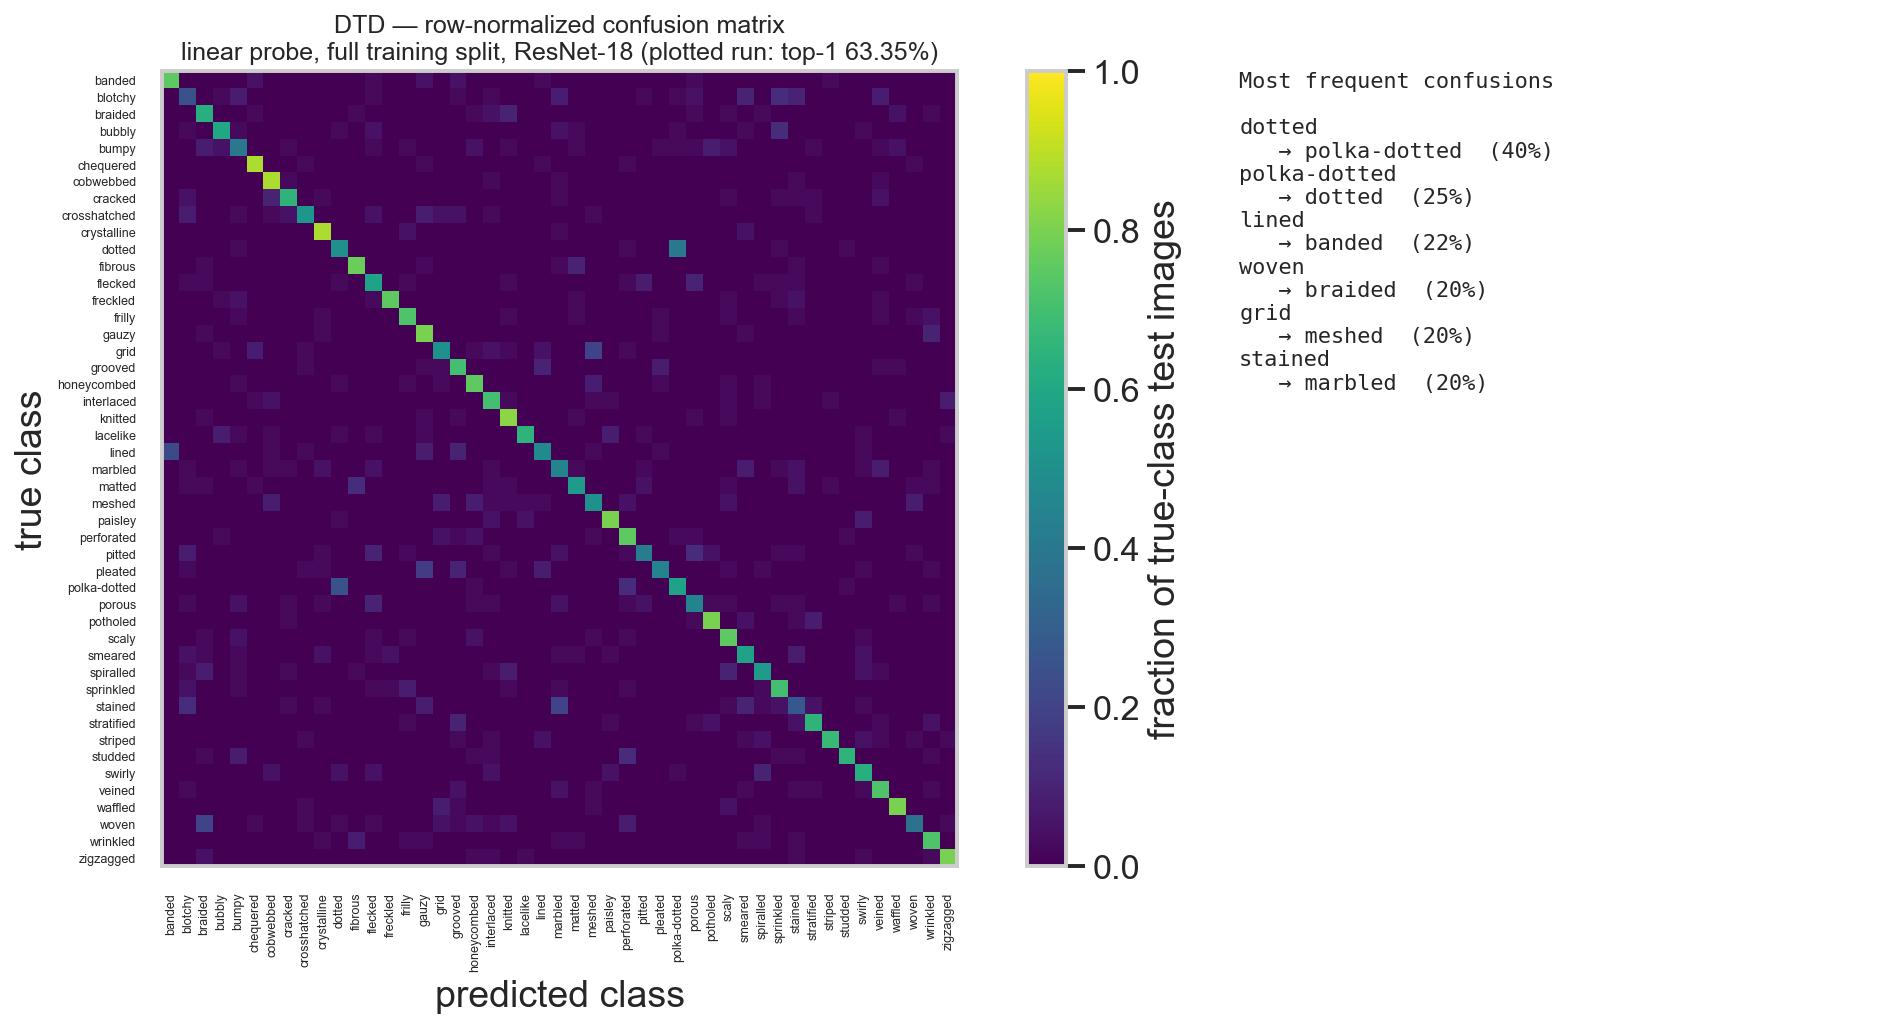

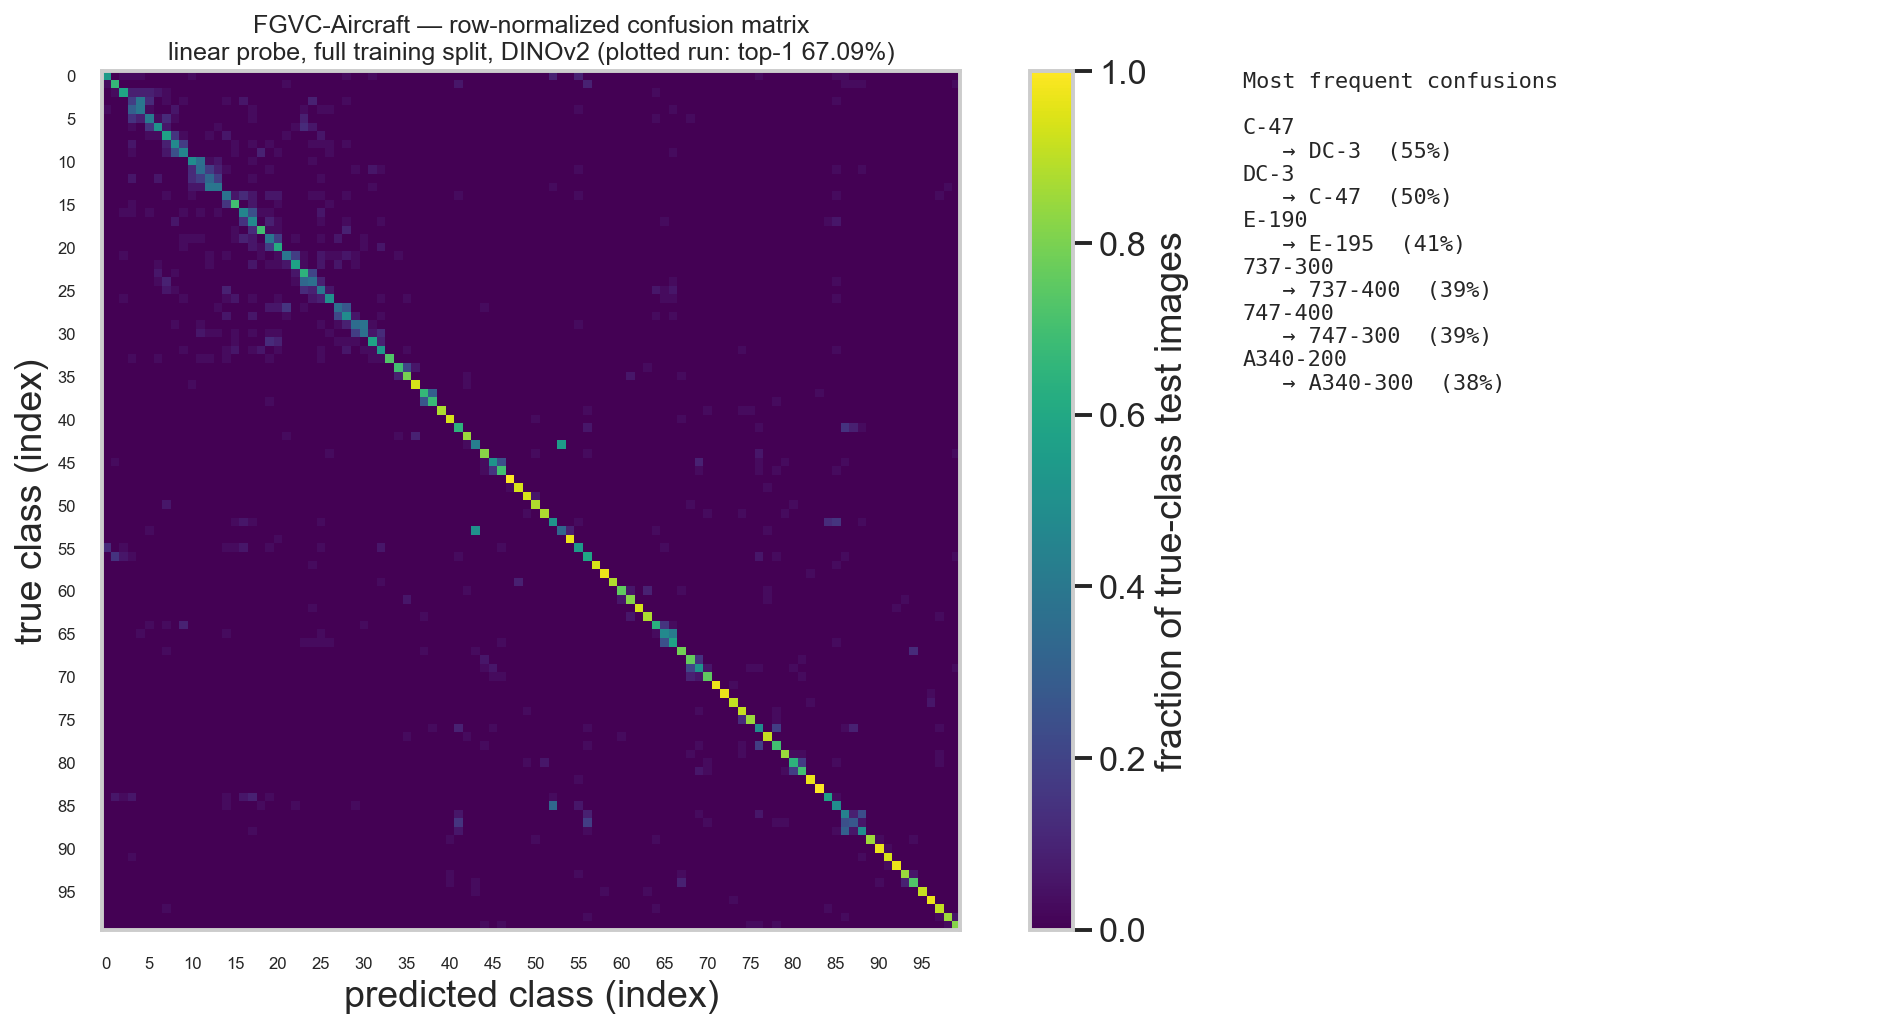

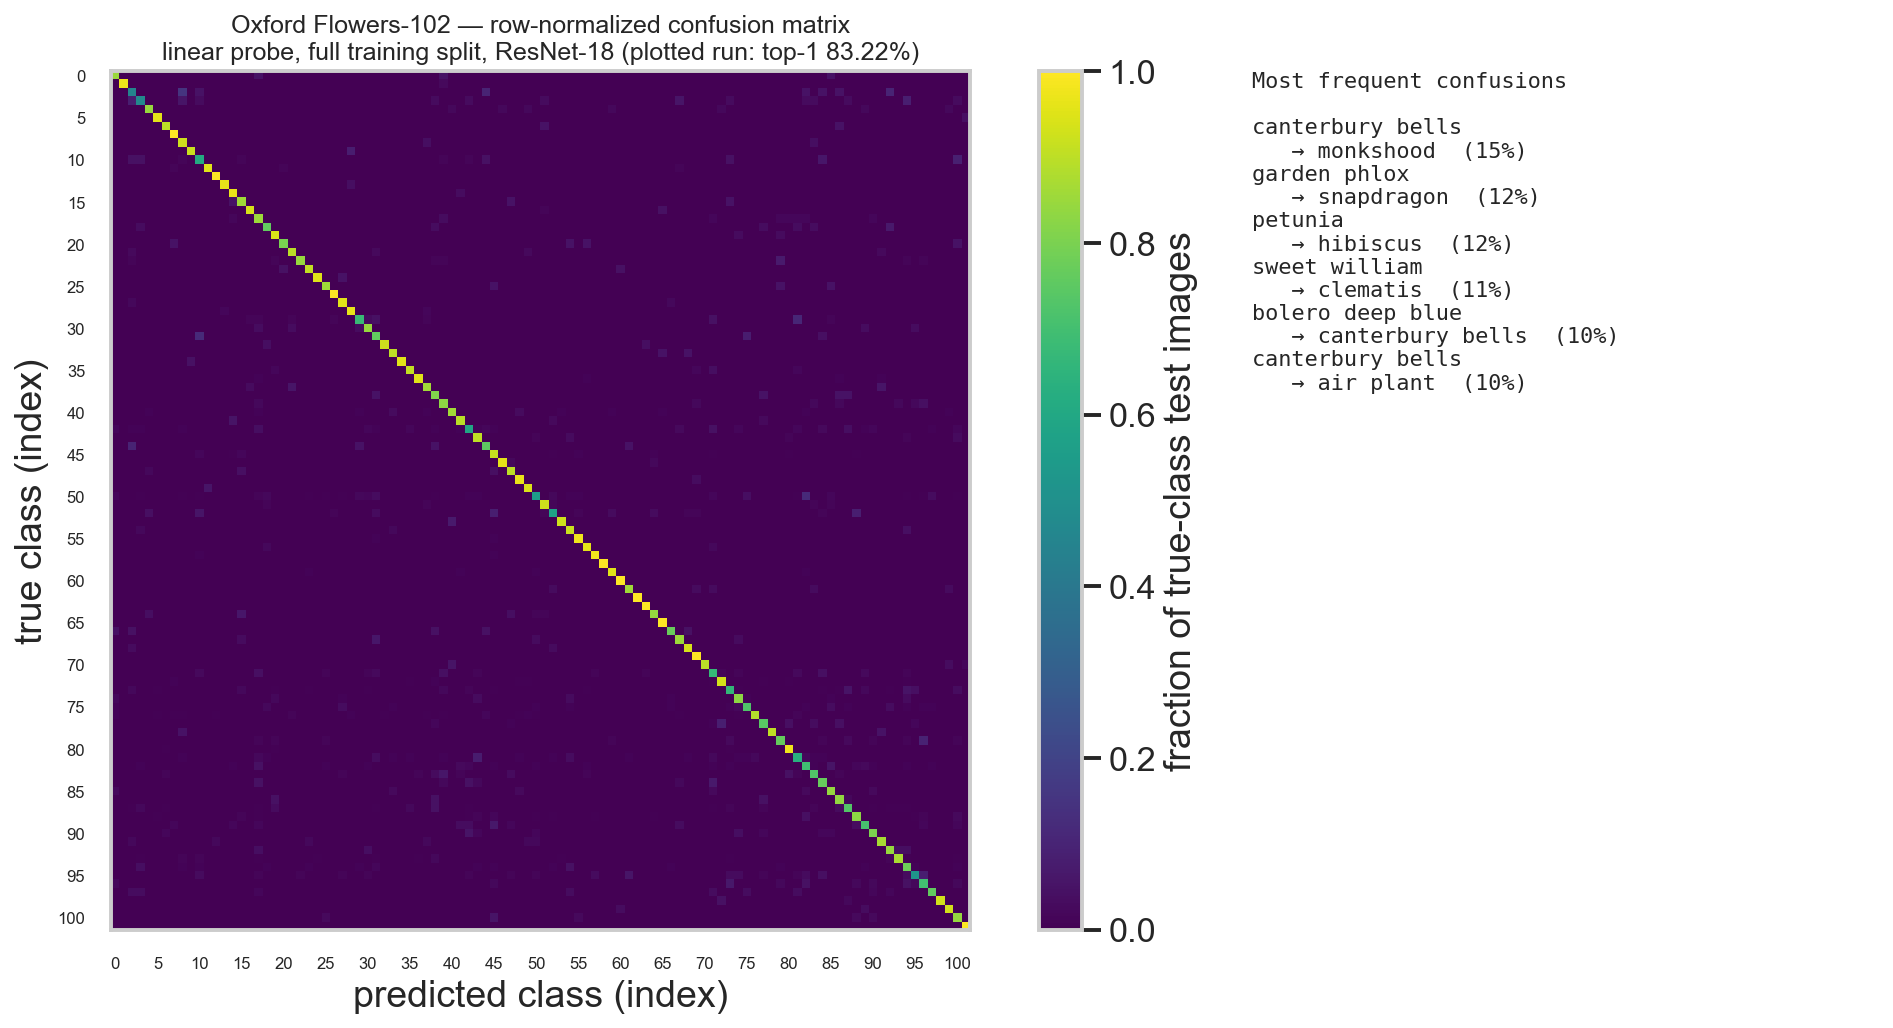

In [11]:
for ds in ("dtd", "fgvc_aircraft", "flowers102"):
    display(Image(str(REPO / "results" / "figures" / f"confusion_{ds}.png"), width=1000))

### 5.5 Feature visualizations

Ten classes per dataset (chosen once with a fixed seed) with up to 40 test images each. For a given dataset the **same classes, the same test examples and the same class colours** are used in every panel, so encoders and methods can be compared directly.

Each figure shows two two-dimensional projections of the $L_2$-normalized features — the space in which the cosine classifier actually operates. **PCA is the primary view**: it is deterministic, linear, and its axes and relative distances have a global meaning. **t-SNE is supplementary**: it is useful for revealing local cluster structure, but it preserves only local neighbourhoods — global distances, cluster sizes and absolute coordinates are not meaningful, and coordinates are not comparable across separately fitted panels. Every t-SNE panel uses the same fixed parameters (perplexity 30, PCA initialization, seed 0).

Stars are the class prototypes — image-derived for ResNet-18 and DINOv2, text-derived for CLIP RN50 — and, as the specification requires, **each projection is fitted jointly to the image features and the prototypes shown in it**, so a prototype's position is directly comparable to the points around it. The prototype/feature class order is asserted against the feature caches at figure-generation time.

**What to look for** (reading local neighbourhoods, not global geometry): on FGVC-Aircraft with DINOv2, distinctive light aircraft (Cessna 172, DHC-1, Fokker 50) form tight, well-separated clusters while the Boeing/Airbus narrow- and wide-bodies overlap heavily — a direct visual account of where the remaining ~33% of errors come from. The same ten classes under ResNet-18 show visibly weaker local structure, consistent with the accuracy gap between the two encoders.

**In the CLIP panels**, the ten text prototypes appear close to one another and separated from the image points in both projections. This is *consistent with* the modality gap reported for CLIP-style models in the literature (image and text embeddings concentrating in different regions of the joint space), but a 2-D projection — especially t-SNE — cannot establish that on its own; confirming it would require distance measurements in the original 1024-d space. Either way it does not indicate a broken classifier: zero-shot classification depends only on the *relative* cosine ordering of a query against the text prototypes, never on absolute image–text proximity.

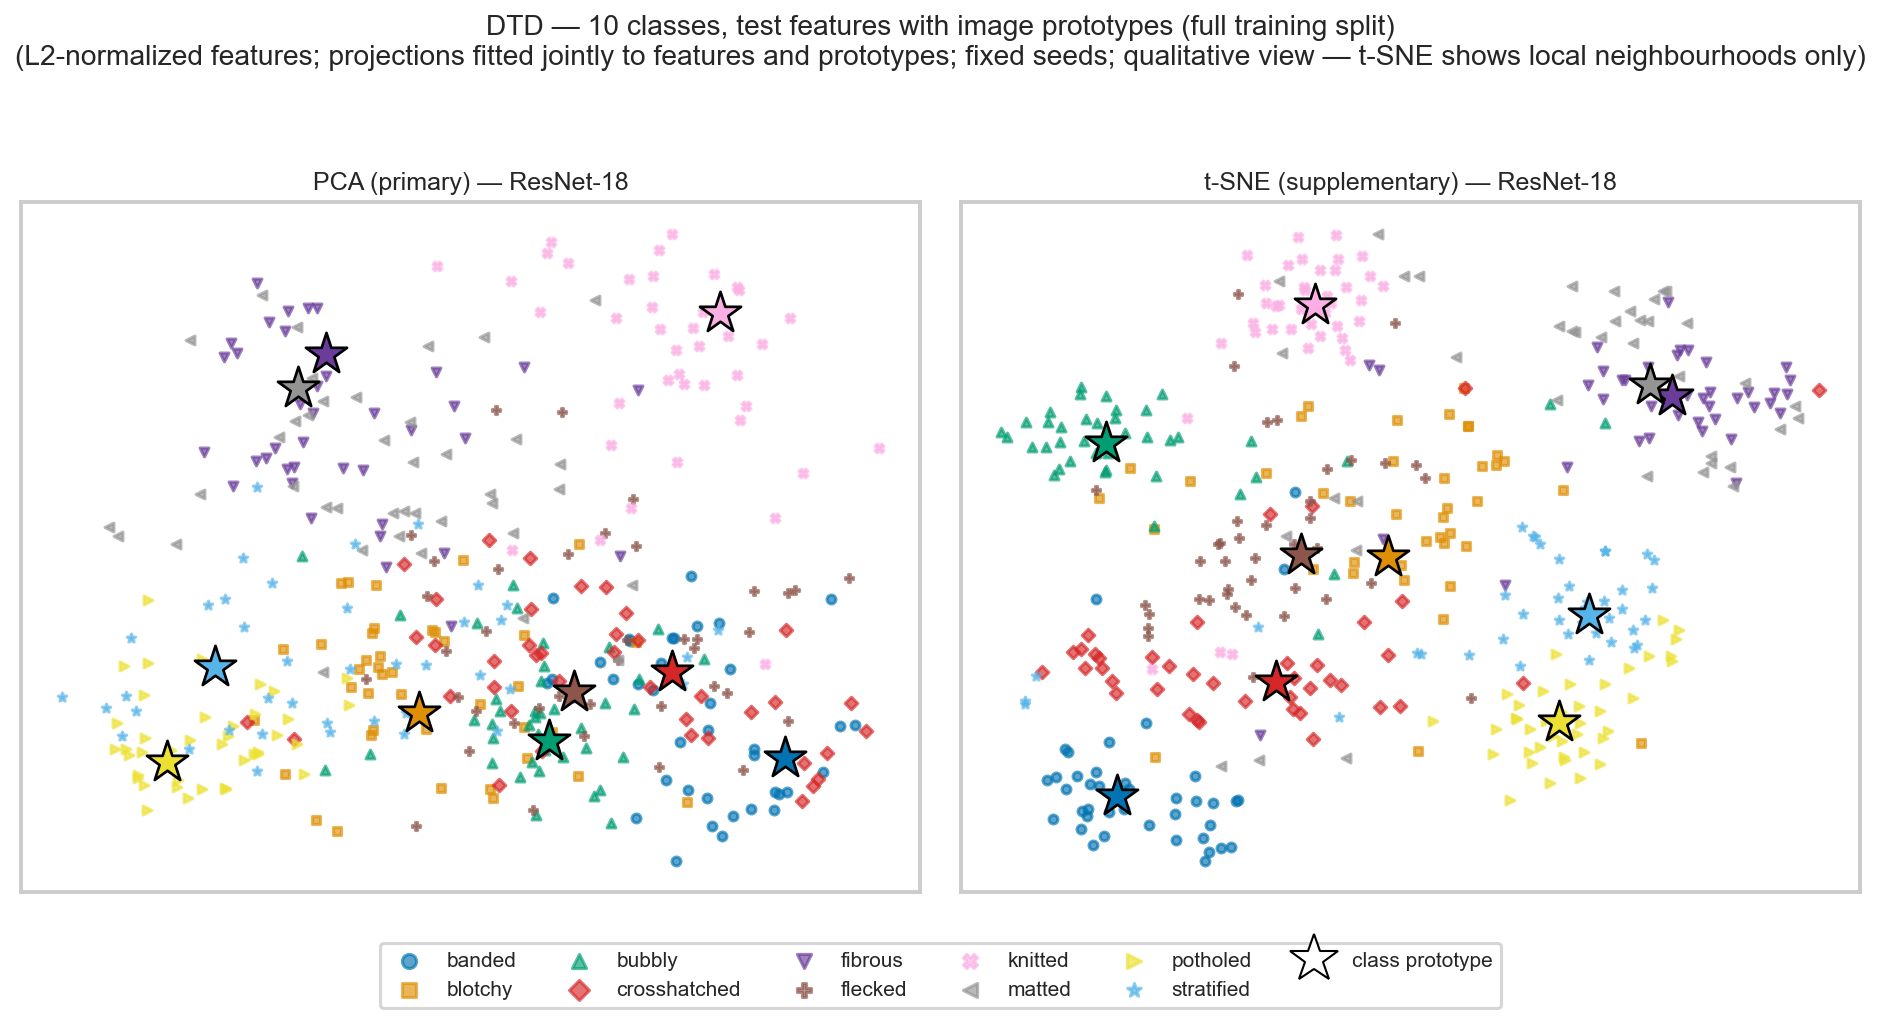

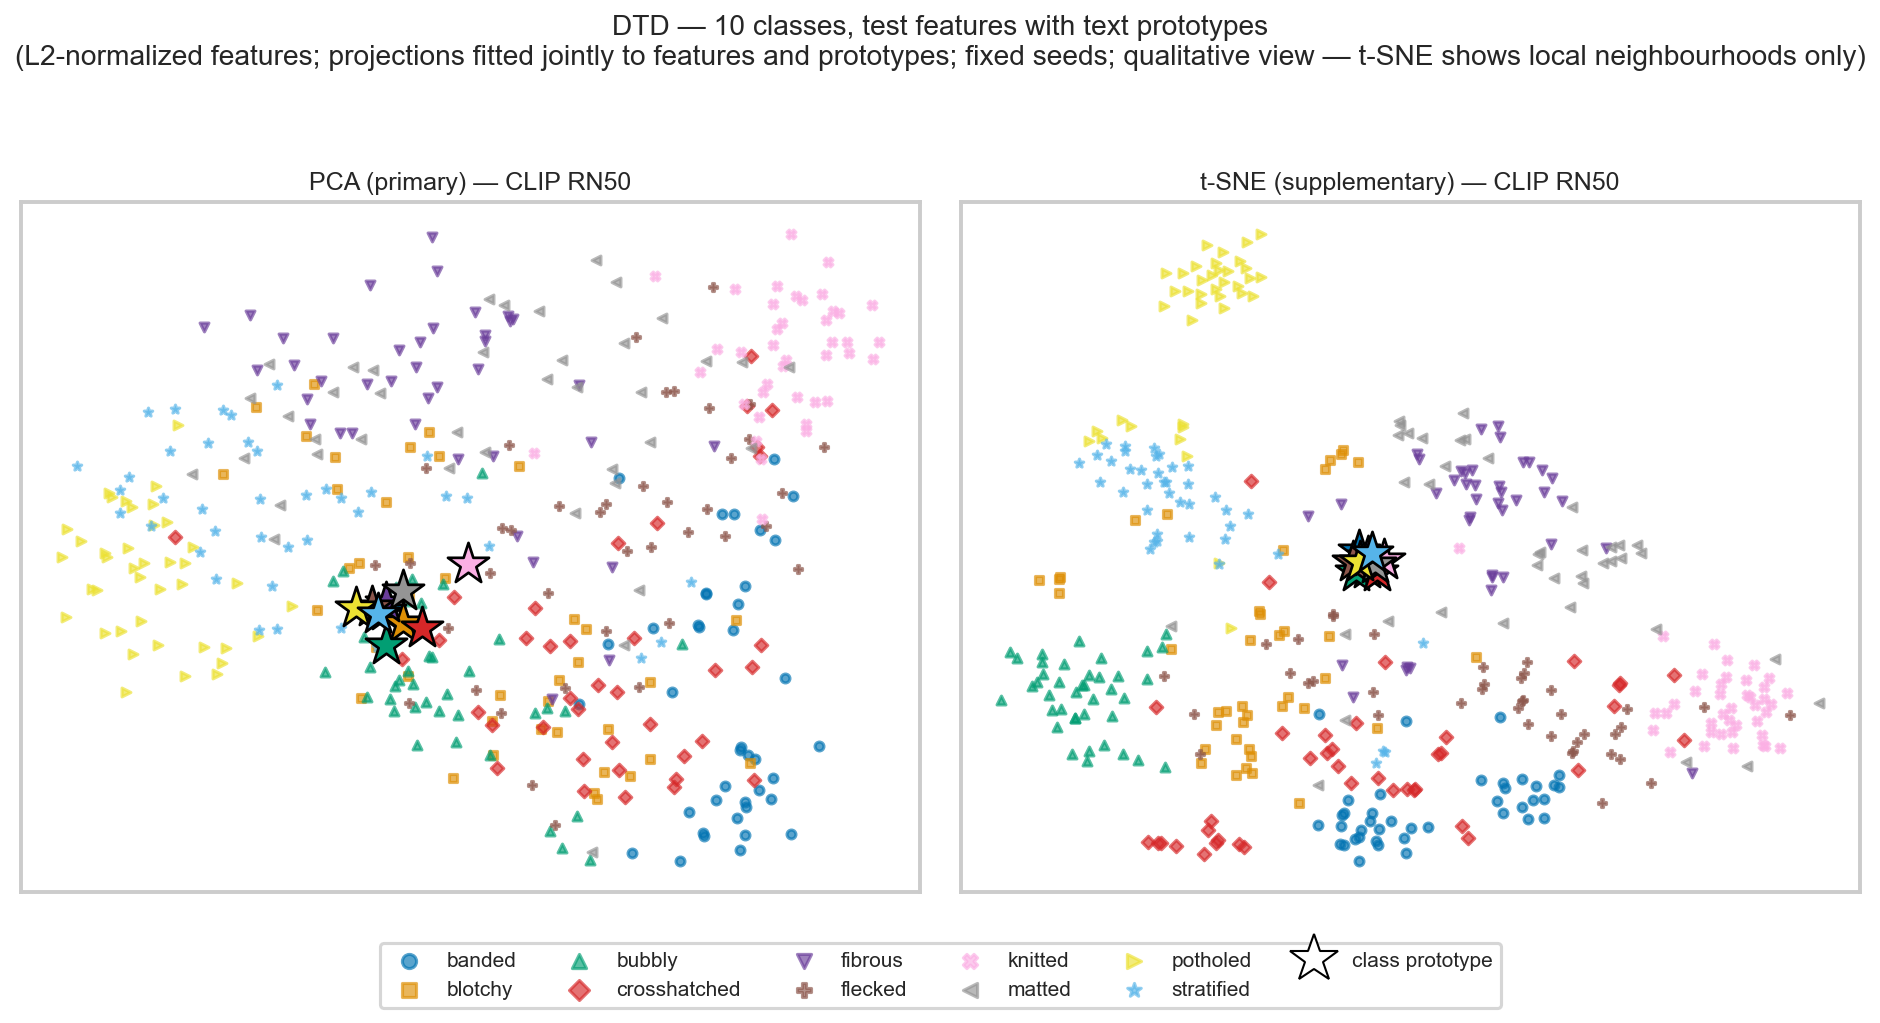

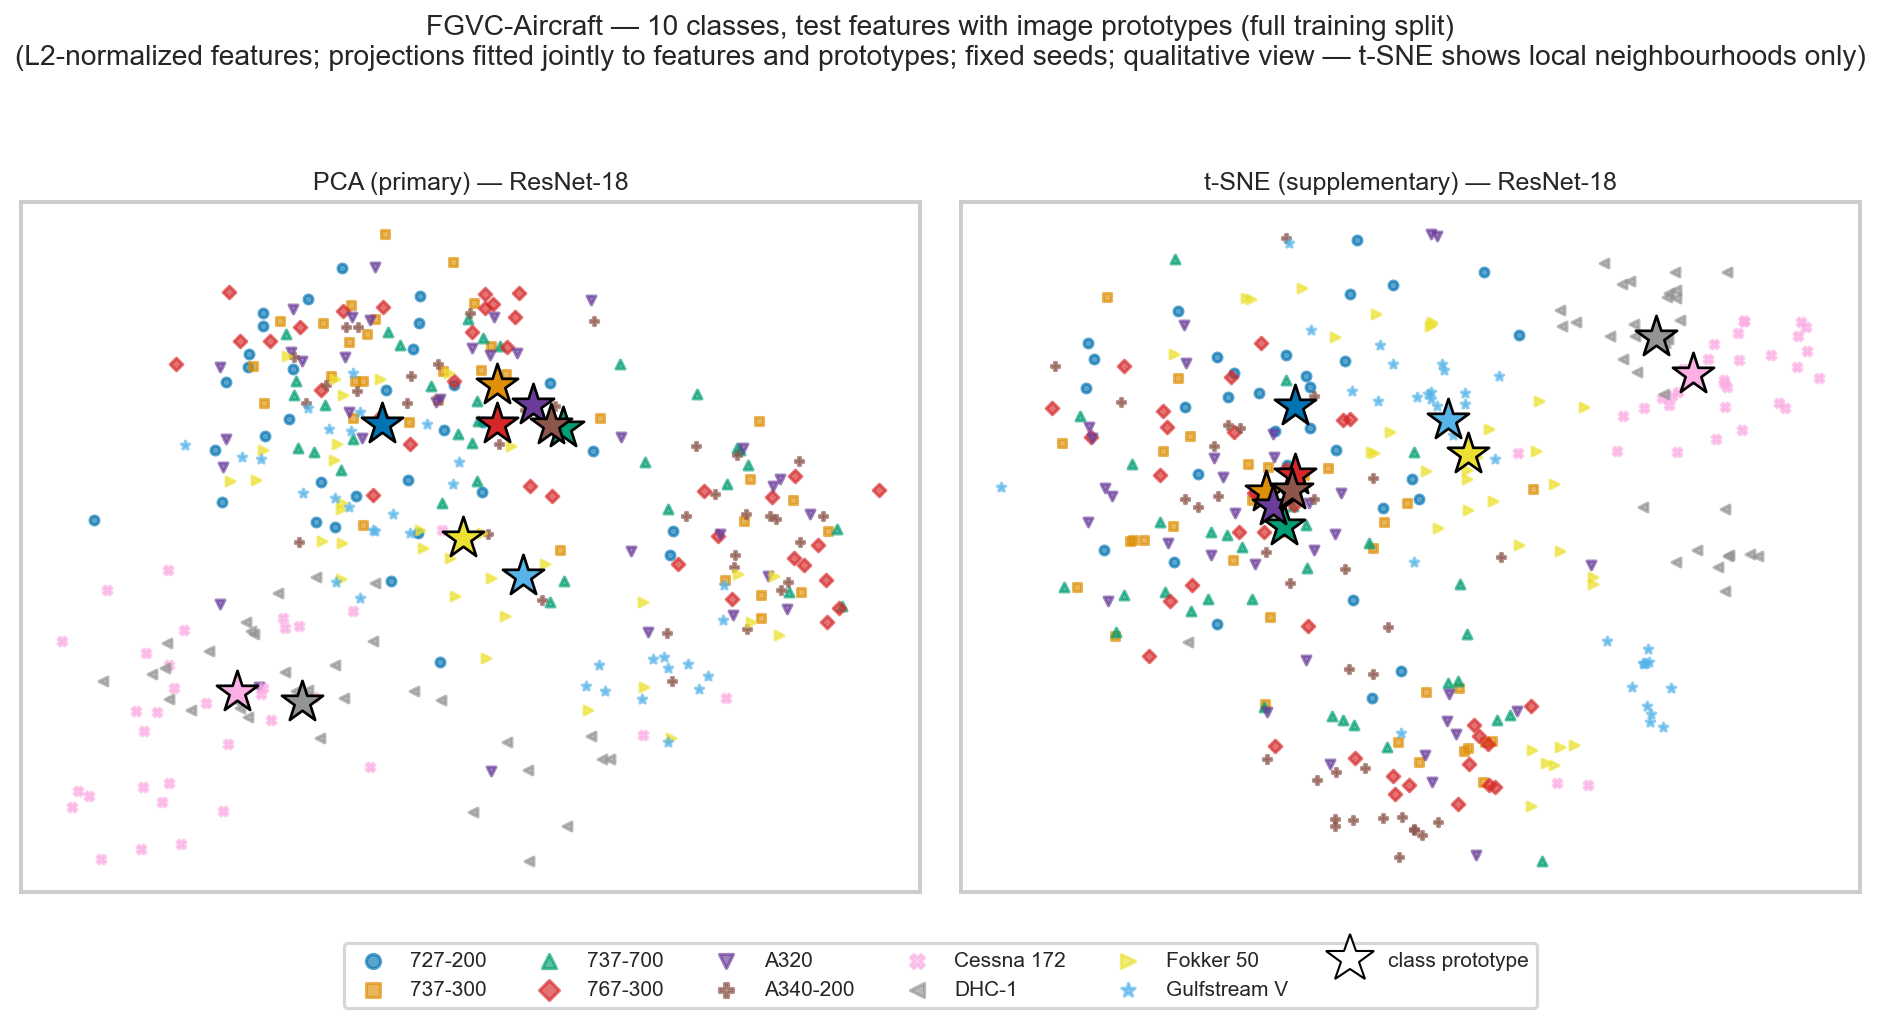

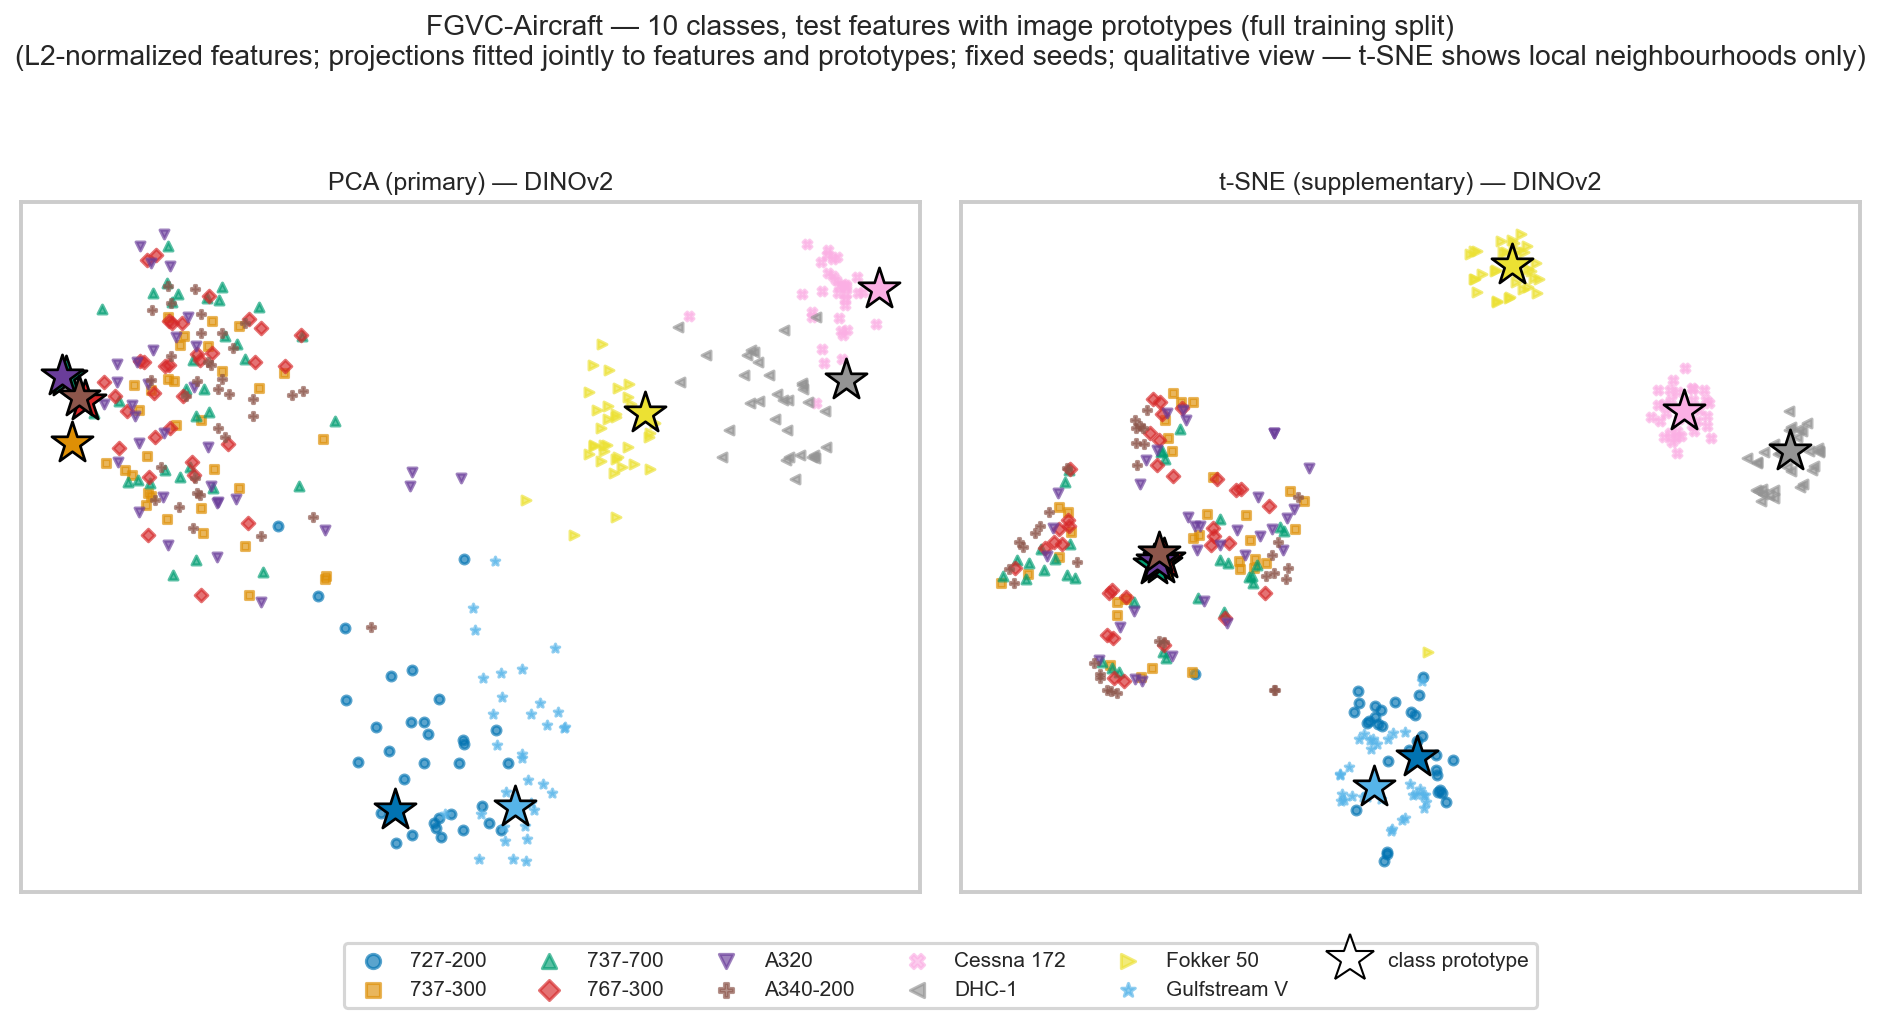

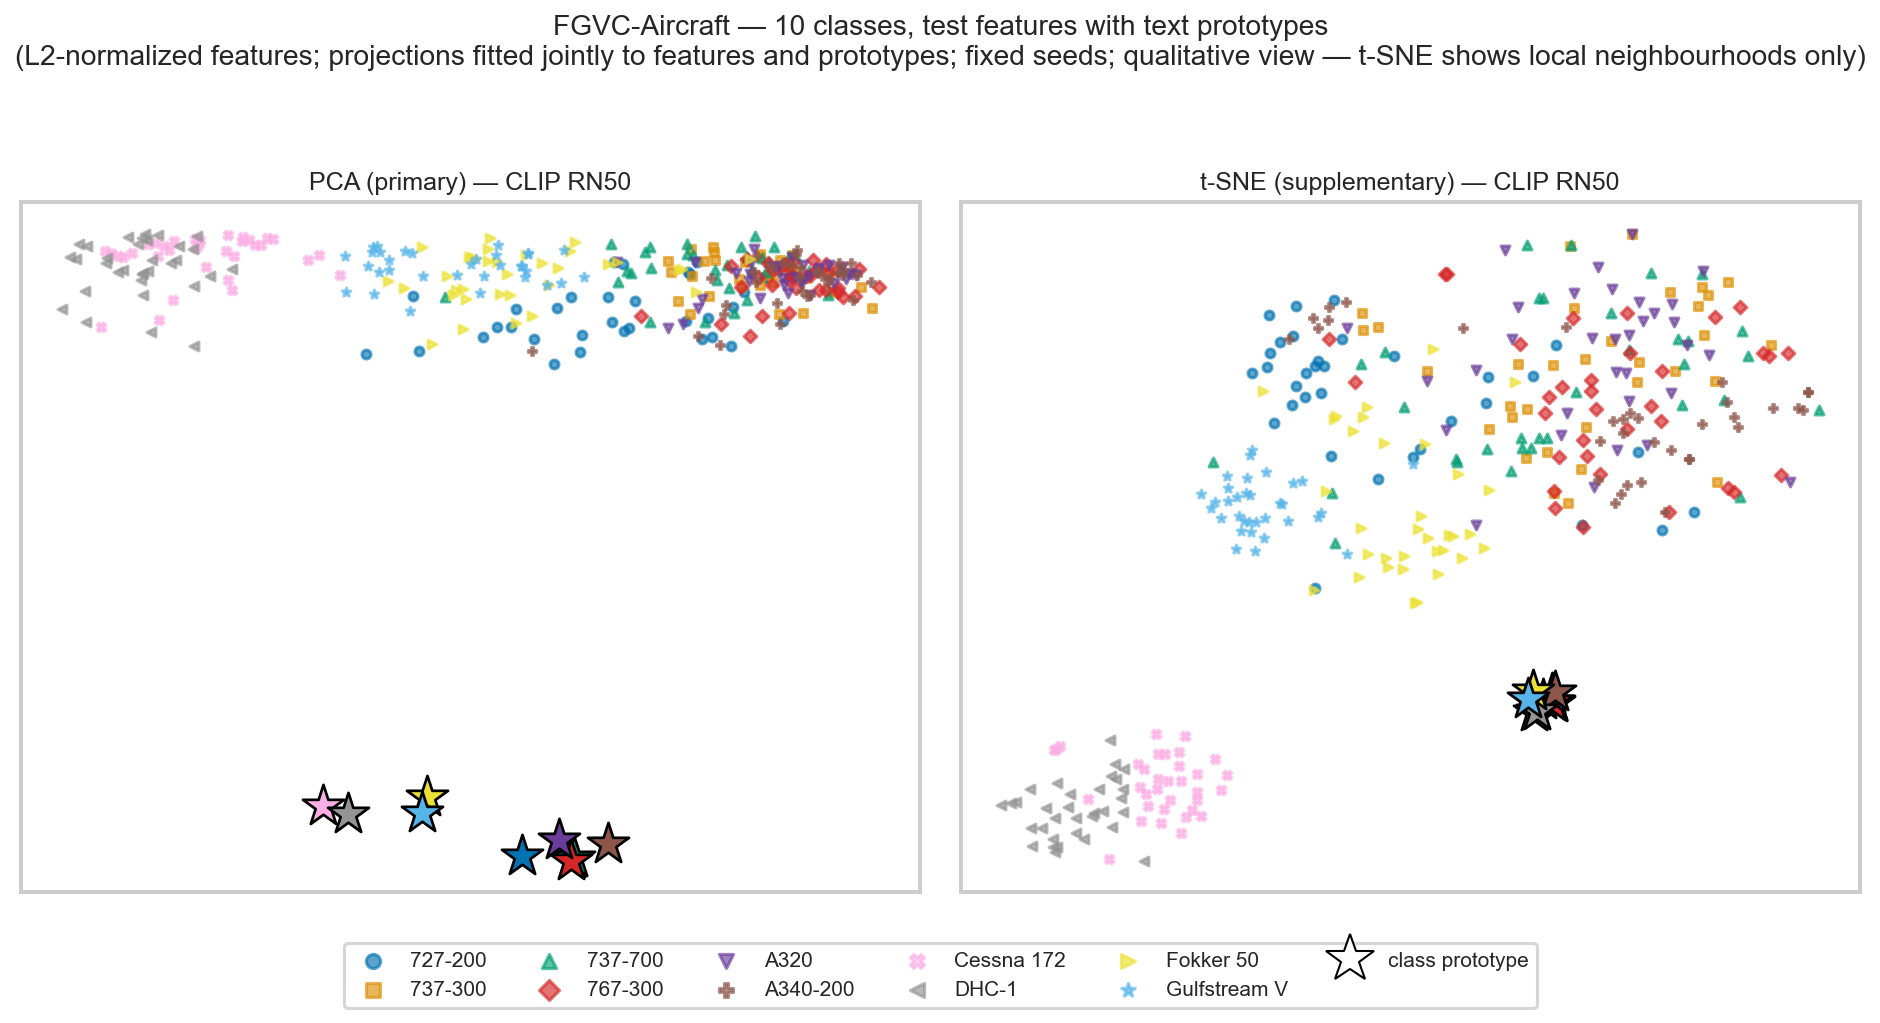

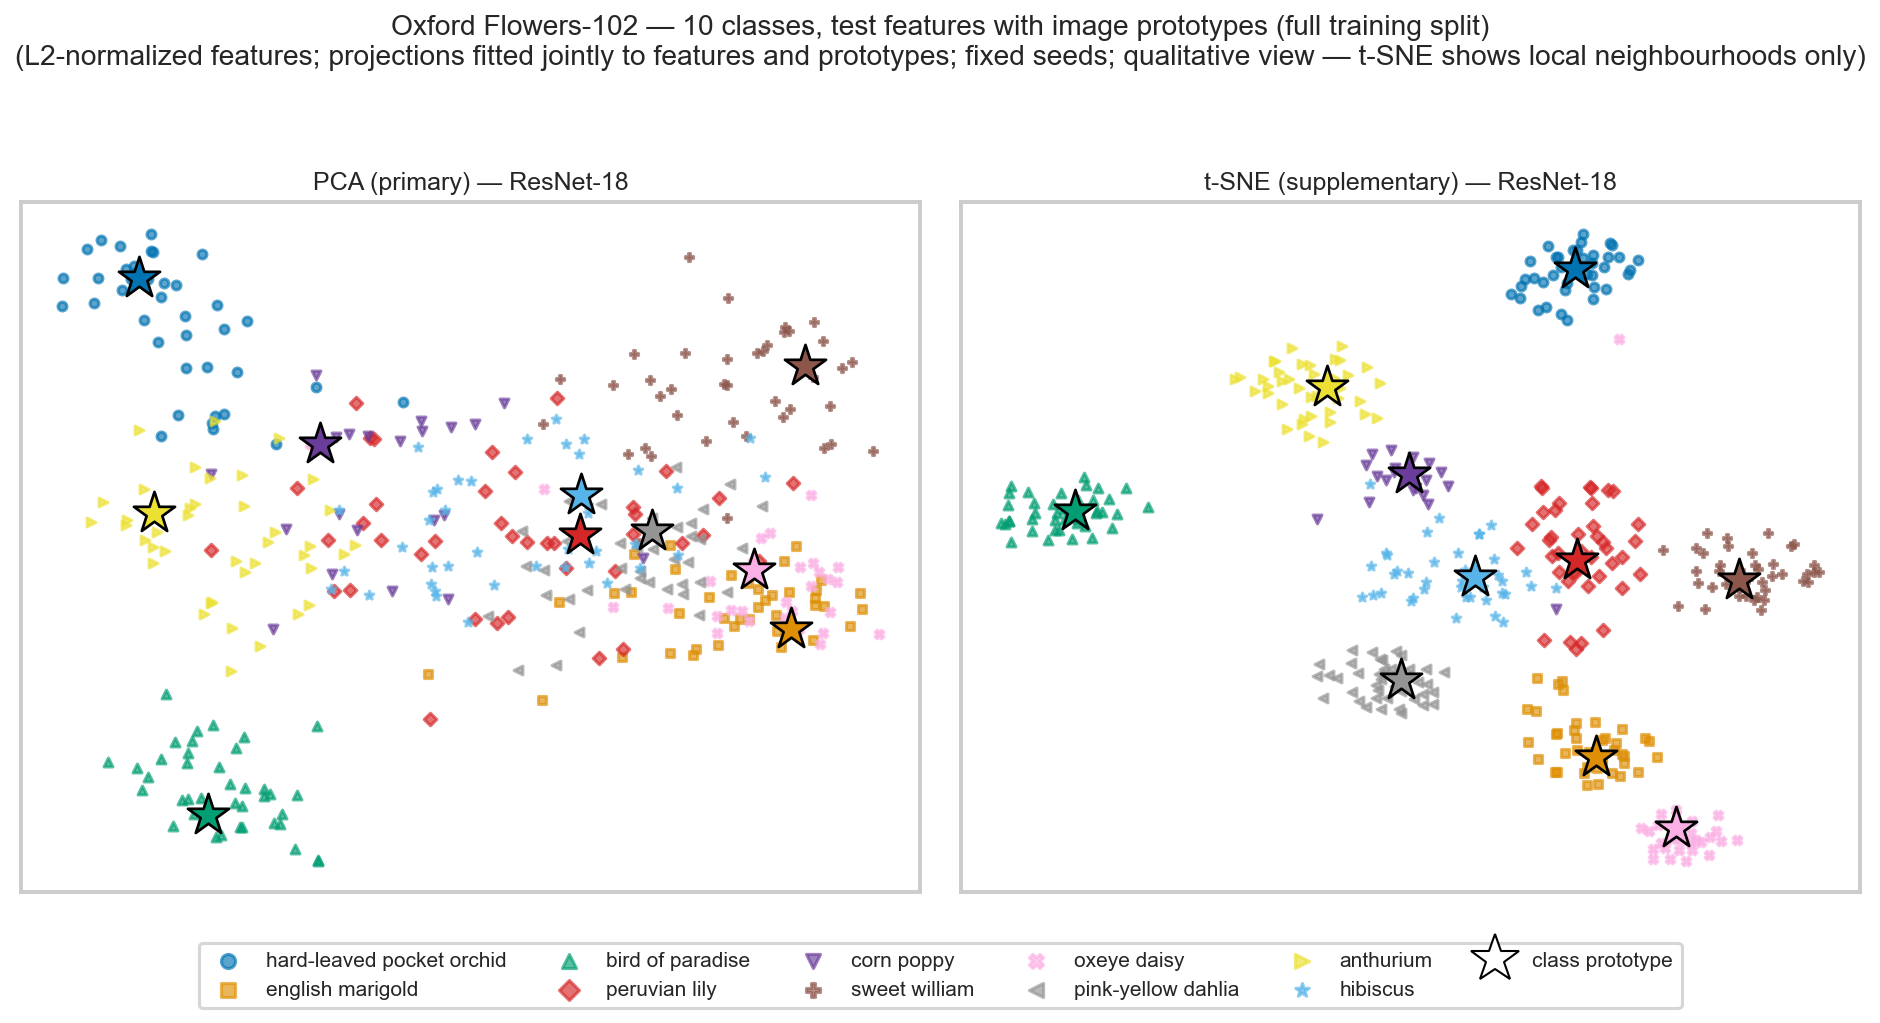

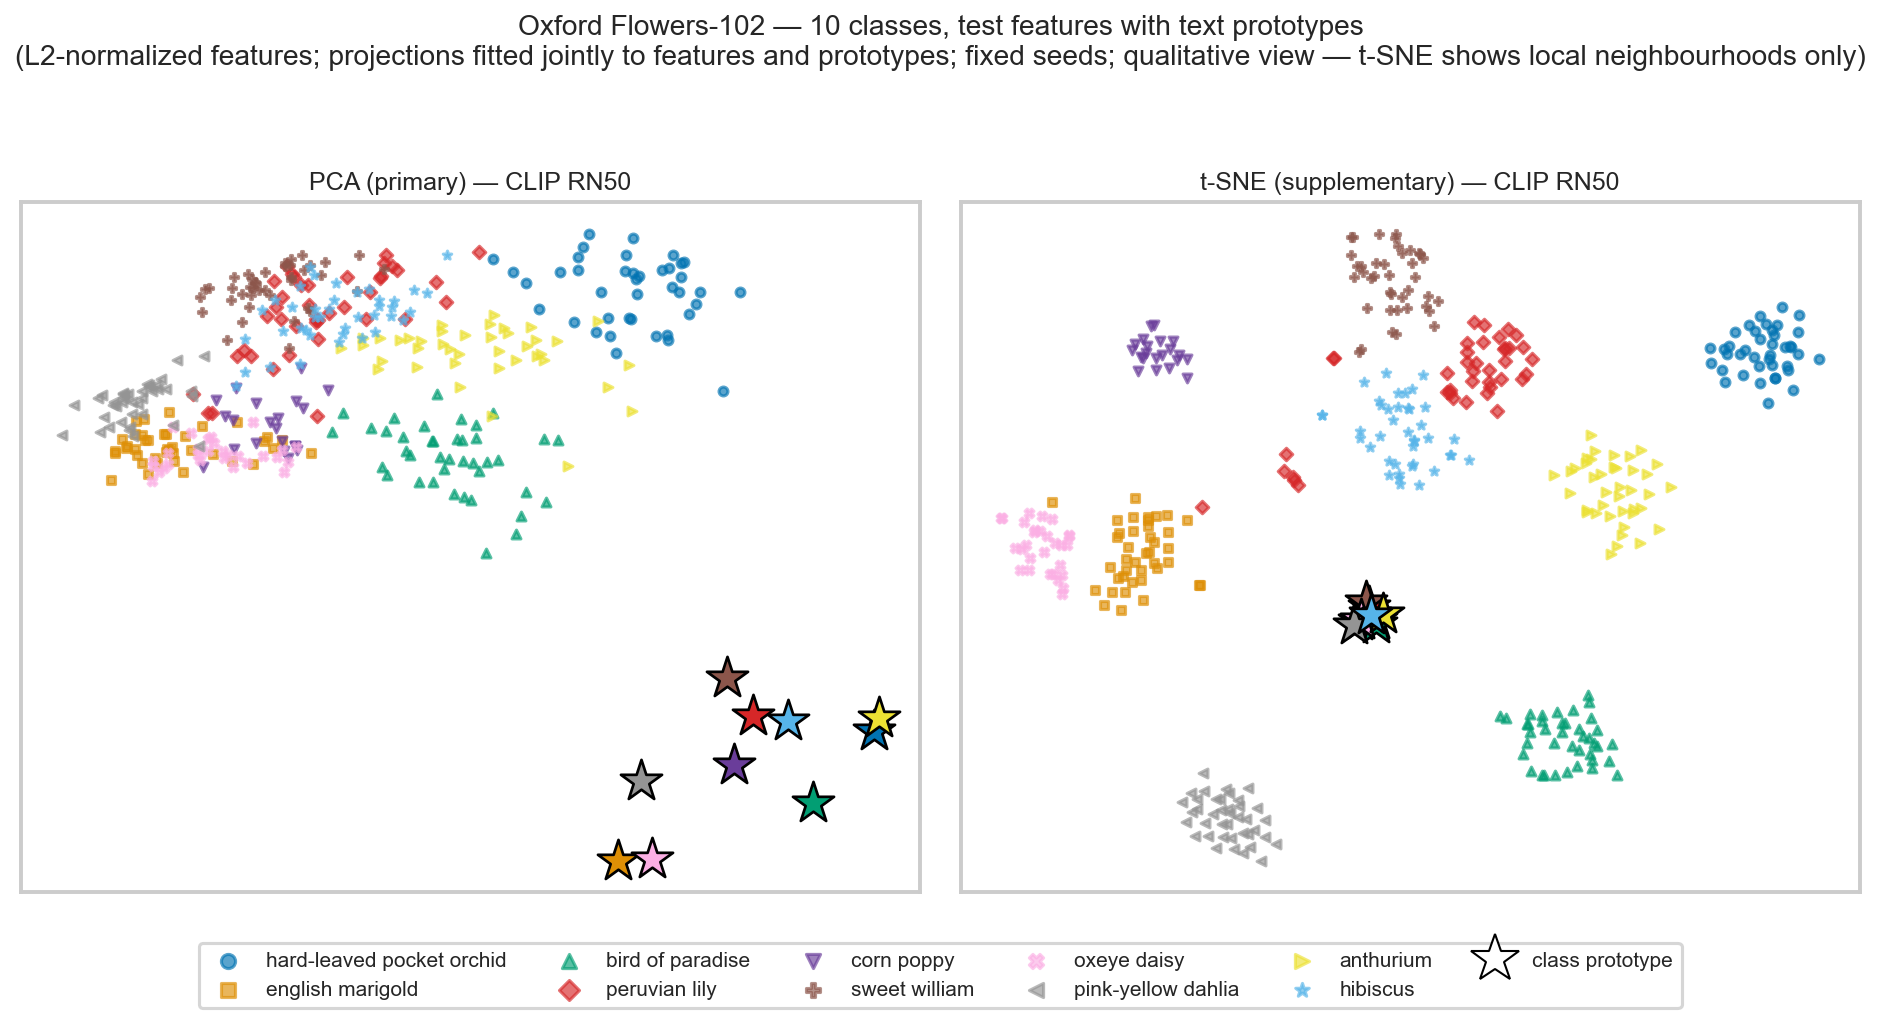

In [12]:
for name in ("features_dtd_resnet18.png", "features_dtd_clip_rn50.png",
             "features_fgvc_aircraft_resnet18.png", "features_fgvc_aircraft_dinov2_vits14.png",
             "features_fgvc_aircraft_clip_rn50.png",
             "features_flowers102_resnet18.png", "features_flowers102_clip_rn50.png"):
    p = REPO / "results" / "figures" / name
    if p.exists():
        display(Image(str(p), width=980))

## 6 · Discussion

The observations below are read directly off the tables and figures above; the numbers are loaded from `results/metrics/`, never typed by hand.

**The representation dominates the head.** On FGVC-Aircraft, swapping ResNet-18 for DINOv2 while holding everything else fixed moves the full-split linear probe from 36.62% to 67.21% — a 30.6-point gain, far larger than any difference between heads on a fixed encoder. Put sharply: the DINOv2 probe trained on **5 images per class** (36.47 ± 0.70) matches, within run-to-run noise, the ResNet-18 probe trained on the **entire** training split (36.62 ± 0.27).

**Prototypes win only in the lowest-data regime, and only once.** The image-prototype head beats the linear probe at exactly one cell of the grid — DTD at K = 5, paired +0.90 ± 0.14 with all three seeds agreeing (§5.1) — and at DTD K = 10 the two are statistically indistinguishable at n = 3. Everywhere else the probe wins decisively, by a margin that widens with training-set size. A class mean is a well-conditioned estimator when five examples are all you have, but it cannot exploit extra data the way a trained boundary can.

**Zero-shot CLIP is a different trade-off, not a weaker version of the same one.** It uses no labeled training images at all: 63.6% on Flowers-102, 39.8% on DTD, 17.0% on FGVC-Aircraft. The ordering tracks how describable the classes are in natural language — flowers and textures have names that carry visual meaning, aircraft *variants* essentially do not ("a photo of a 737-300 aircraft" says very little).

**Overfitting is real where it appears, and the protocol absorbs it** — see the training curves and the loss-versus-accuracy divergence discussed in §5.3 (three of the four saved 10-shot curves overfit; Flowers-102 does not).

In [13]:
from src.visualize import dataset_label, encoder_label, head_label

s = pd.read_csv(REPO / "results" / "metrics" / "summary.csv")
s["Dataset"] = s["dataset"].map(dataset_label)
s["Encoder"] = s["encoder"].map(lambda e: encoder_label(e, short=True))
s["Baseline"] = s["head"].map(head_label)
s["Accuracy (%)"] = (100 * s["mean_acc"]).round(2).astype(str)
s.loc[s["n_runs"] > 1, "Accuracy (%)"] += " ± " + (100 * s.loc[s["n_runs"] > 1, "std_acc"]).round(2).astype(str)

print("Best configuration per dataset (all baselines, any training-set size):")
display(s.loc[s.groupby("dataset")["mean_acc"].idxmax()][
    ["Dataset", "Encoder", "Baseline", "k_shot", "Accuracy (%)"]].rename(
        columns={"k_shot": "Training-set size"}).reset_index(drop=True))

print("\nAccuracy (%) by training-set size, and the gain from 5-shot to the full split:")
piv = s.pivot_table(index=["Dataset", "Encoder", "Baseline"], columns="k_shot",
                    values="mean_acc")
piv = (100 * piv).round(2)
piv["gain 5 → full (pts)"] = (piv["full"] - piv["5shot"]).round(2)
display(piv.dropna(subset=["gain 5 → full (pts)"])[
    ["5shot", "10shot", "full", "gain 5 → full (pts)"]])

Best configuration per dataset (all baselines, any training-set size):


,Dataset,Encoder,Baseline,Training-set size,Accuracy (%)
0,DTD,ResNet-18,Linear probe,full,62.84 ± 0.45
1,FGVC-Aircraft,DINOv2,Linear probe,full,67.21 ± 0.11
2,Oxford Flowers-102,ResNet-18,Linear probe,full,83.28 ± 0.11



Accuracy (%) by training-set size, and the gain from 5-shot to the full split:


k_shot                                         5shot  10shot   full  \
Dataset            Encoder   Baseline                                 
DTD                ResNet-18 Image prototypes  46.51   53.37  58.78   
                             Linear probe      45.60   54.31  62.84   
FGVC-Aircraft      DINOv2    Image prototypes  23.11   27.80  34.41   
                             Linear probe      36.47   51.30  67.21   
                   ResNet-18 Image prototypes  16.04   19.85  25.20   
                             Linear probe      19.90   27.36  36.62   
Oxford Flowers-102 ResNet-18 Image prototypes  70.19   75.22  75.22   
                             Linear probe      75.58   83.22  83.28   

k_shot                                         gain 5 → full (pts)  
Dataset            Encoder   Baseline                               
DTD                ResNet-18 Image prototypes                12.27  
                             Linear probe                    17.24  
FGVC-Aircraft      DINOv2    Image prototypes                11.30  
                             Linear probe                    30.74  
                   ResNet-18 Image prototypes                 9.16  
                             Linear probe                    16.72  
Oxford Flowers-102 ResNet-18 Image prototypes                 5.03  
                             Linear probe                     7.70

### Which prototype branch carries into Stage 2 — decision

**Selected: Option A, image-derived class prototypes.** The selection rests on methodological considerations and **validation data only — test accuracy plays no role in it.** Three of the four reasons are structural properties of the branches that need no accuracy numbers at all; the fourth is measured on the validation split:

1. **Experimental surface** *(methodological)* — image prototypes depend on both the encoder and K, so Stage 2 inherits a grid of transport targets (3 training sizes × the cached encoders) rather than one fixed text embedding per class.
2. **Encoder freedom** *(methodological)* — Option A can be built on any cached representation, including DINOv2 on the fine-grained task; Option B is locked to CLIP RN50 by construction.
3. **Continuity with Stage 3** *(methodological)* — Option A reuses exactly the caches the linear probe uses, so the Stage-2 and Stage-3 comparisons rest on the same representation.
4. **Headroom, measured on validation** — full-split prototype vs full-split probe **validation** accuracy on the same features (from `runs.csv`, `val_acc`; the prototype head is deterministic, so its validation accuracy involves no training or selection): the cell below computes the gaps.

Both branches are implemented and reported, so this selection can be revisited without re-running anything.

In [14]:
runs = pd.read_csv(REPO / "results" / "metrics" / "runs.csv")
g = runs[runs["k_shot"] == "full"].copy()
rows = []
for ds, gd in g.groupby("dataset", sort=False):
    probe_val = gd[gd["head"] == "linear_probe"].groupby("encoder")["val_acc"].mean()
    enc = probe_val.idxmax()  # encoder selected on VALIDATION accuracy
    proto = gd[(gd["head"] == "image_prototype") & (gd["encoder"] == enc)]["val_acc"]
    rows.append({"Dataset": dataset_label(ds),
                 "Encoder (selected on val)": encoder_label(enc, short=True),
                 "Probe val acc (%)": round(100 * probe_val[enc], 2),
                 "Prototype val acc (%)": round(100 * float(proto.iloc[0]), 2),
                 "Validation headroom (pts)": round(100 * (probe_val[enc] - float(proto.iloc[0])), 2)})
print("Branch-selection evidence — validation split only (test accuracy unused):")
display(pd.DataFrame(rows))

Branch-selection evidence — validation split only (test accuracy unused):


,Dataset,Encoder (selected on val),Probe val acc (%),Prototype val acc (%),Validation headroom (pts)
0,DTD,ResNet-18,60.71,55.37,5.34
1,FGVC-Aircraft,DINOv2,68.62,32.91,35.70
2,Oxford Flowers-102,ResNet-18,86.50,78.04,8.46


### Which two datasets carry forward — decision

The specification asks for two of the three datasets; we ran all three (the third marked ‡ throughout) precisely so this choice could be made on evidence instead of blind. **Selected pair: DTD + FGVC-Aircraft.** The selection is *structural* — it rests on properties of the official splits that the completed runs made concrete, not on ranking test accuracies:

1. **Flowers-102's training-size axis is degenerate.** Its official training split holds exactly 10 images per class, so its 10-shot setting *is* its full setting: the cell below shows the image-prototype head (deterministic) scores identically at 10-shot and full, and the probe's three 10-shot "subset seeds" all select the same images, so its 10-shot spread is exactly zero. Its accuracy-vs-training-size curve has two distinct points where the other datasets have three — and that axis is exactly the one Stage 2 argues along.
2. **DTD and FGVC-Aircraft give three genuinely distinct K settings** (40 and ~33 training images per class), so 5-shot, 10-shot and full are all informative.
3. **FGVC-Aircraft carries the DINOv2 requirement and the headroom.** It is the fine-grained, lowest-accuracy task — the largest validation probe-vs-prototype gap (35.7 points, table above) and therefore the most room for a Flow-Matching layer to demonstrate a gain.
4. **Flowers-102's test split is class-imbalanced** (20–238 images per class), making its top-1 the least clean single number of the three (§5.1, macro vs top-1).

Flowers-102 stays in this report as the ‡ extension — the degeneracy is instructive and the numbers are published — but Stage 2 and Stage 3 build on DTD + FGVC-Aircraft.

In [15]:
splits = pd.read_csv(REPO / "results" / "metrics" / "dataset_splits.csv")
train_pc = splits[splits["split"] == "train"].set_index("dataset")["per_class_median"]

s = pd.read_csv(REPO / "results" / "metrics" / "summary.csv")
rows = []
for ds in ("dtd", "fgvc_aircraft", "flowers102"):
    # ResNet-18 is the one encoder present on every dataset, so the rows are comparable.
    # NB: s["head"], not s.head — .head is the DataFrame method.
    proto = s[(s["dataset"] == ds) & (s["encoder"] == "resnet18")
              & (s["head"] == "image_prototype")].set_index("k_shot")
    probe = s[(s["dataset"] == ds) & (s["encoder"] == "resnet18")
              & (s["head"] == "linear_probe")].set_index("k_shot")
    rows.append({
        "Dataset": dataset_label(ds),
        "Train imgs/class": int(train_pc[ds]),
        "Prototype: full − 10-shot (pts)": round(100 * (proto.loc["full", "mean_acc"] - proto.loc["10shot", "mean_acc"]), 2),
        "Probe: full − 10-shot (pts)": round(100 * (probe.loc["full", "mean_acc"] - probe.loc["10shot", "mean_acc"]), 2),
        "Probe 10-shot spread (± pts)": round(100 * probe.loc["10shot", "std_acc"], 2),
    })
print("Pair-selection evidence — the 10-shot ≡ full degeneracy is a property of the split, visible in the runs:")
display(pd.DataFrame(rows))

Pair-selection evidence — the 10-shot ≡ full degeneracy is a property of the split, visible in the runs:


,Dataset,Train imgs/class,Prototype: full − 10-shot (pts),Probe: full − 10-shot (pts),Probe 10-shot spread (± pts)
0,DTD,40,5.41,8.53,0.28
1,FGVC-Aircraft,33,5.35,9.26,0.83
2,Oxford Flowers-102,10,0.00,0.07,0.00


### Limitations

- Frozen encoders bound absolute accuracy by design; no adaptation of the representation is attempted at this stage.
- The linear-probe configuration is the specification's suggested baseline, adopted without search. Better per-dataset numbers are certainly reachable, but tuning was explicitly out of scope and would have to be done on the validation split.
- Flowers-102's official training split contains exactly 10 images per class, so its 10-shot and full settings coincide and its three 10-shot runs are identical by construction (hence the exact 0.00 spread). Its test split is also class-imbalanced, so top-1 and macro accuracy differ (§5.1).
- Two-dimensional feature projections are qualitative only; t-SNE in particular preserves local neighbourhoods, not global distances (§5.5).
- One seed governs both weight initialization and minibatch ordering, so the "full" spread measures optimization stochasticity as a whole rather than initialization in isolation.

### Deviations from, and extensions beyond, the specification

| Item | Status | Note |
|---|---|---|
| Third dataset (Flowers-102) | extension ‡ | spec allows any two; running all three let the pair be *chosen on evidence* — DTD + FGVC-Aircraft, confirmed post-results on structural grounds (decision above) |
| Both prototype branches | extension | spec asks for one; implementing both let the Stage-2 branch be chosen on methodological + validation evidence |
| Linear-probe configuration | **as specified** | AdamW / 1e-3 / 1e-4 / 64 / ≤200 epochs / best-val-accuracy checkpoint, unchanged |
| DINOv2 coverage | **as specified** | one dataset (FGVC-Aircraft) |
| CLIP RN50 usage | **as specified** | zero-shot branch only; never a probe or prototype backbone |
| Feature visualizations | **as specified**, both projections | PCA (primary) *and* t-SNE (supplementary); the spec allows either |

## 7 · Stage-2/3 handoff

The concrete configuration each later stage builds on. Encoder selection uses **validation** accuracy of the full-split probe; the prototype target follows the branch decision above; the last column is the already-published one-time test read-out that Stage 2/3 must beat.

In [16]:
from IPython.display import Markdown

display(Markdown((REPO / "results" / "metrics" / "handoff_table.md").read_text(encoding="utf-8")))

| Dataset | Selected encoder (by validation) | Stage-2 prototype target (branch A) | Validation headroom (probe − prototypes, full) | Stage-3 baseline: linear probe, full split (test) |
|---|---|---|---|---|
| DTD | ResNet-18 | class-mean prototypes $\mu_c$ of the selected training subset, ResNet-18 features | 60.71 − 55.37 = 5.34 pts | 62.84 ± 0.45 |
| FGVC-Aircraft | DINOv2 | class-mean prototypes $\mu_c$ of the selected training subset, DINOv2 features | 68.62 − 32.91 = 35.70 pts | 67.21 ± 0.11 |
| Oxford Flowers-102 ‡ | ResNet-18 | class-mean prototypes $\mu_c$ of the selected training subset, ResNet-18 features | 86.50 − 78.04 = 8.46 pts | 83.28 ± 0.11 |

Encoder selection: highest mean **validation** accuracy of the full-split linear probe (`runs.csv`, `val_acc`); test accuracy plays no role. Validation headroom: full-split probe validation accuracy minus full-split image-prototype validation accuracy on the same encoder — the gap a Stage-2 Flow-Matching decision layer has room to close, measured without touching the test split. The Stage-3 baseline column is the one-time test read-out published in the accuracy table. ‡ = beyond our selected pair.

### Artifact paths

| Artifact | Path |
|---|---|
| Cached frozen features (train/val/test) | `results/features/{dataset}_{split}_{encoder}.pt` |
| Balanced K-shot training-subset indices | `results/artifacts/subsets/{dataset}_k{K}_seed{s}.pt` |
| CLIP RN50 text prototypes | `results/artifacts/clip_text_{dataset}.pt` |
| Per-run and summary results | `results/metrics/runs.csv`, `summary.csv`, `raw/*.npy` |
| Linear-probe training histories | `results/artifacts/curves/*.json` |

Stage 2 keeps the encoder frozen, trains the Flow Matching model to transport embeddings toward the selected training subset's class prototypes, and is evaluated against the prototype baselines of §5.1 on the identical cached features and committed subset files. Stage 3 places the Flow Matching module between the frozen encoder and the linear probe, trained jointly with cross-entropy — the linear-probe baselines reported here are that comparison's reference.